# Physics Verification Plots — Brownian Motion Diffusion
**PHYS 382 Advanced Lab II — Lab 2: Microscopy & Motility**

This notebook produces publication-quality plots that verify three key physics results:

| # | Result | Stokes-Einstein Prediction |
|---|--------|---------------------------|
| **1** | D decreases with increasing viscosity (at constant bead size) | $D = k_BT / 6\pi\eta r \;\Rightarrow\; D \propto 1/\eta$ |
| **2** | D decreases with increasing bead size (at constant viscosity); $\alpha \approx 1$ | $D \propto 1/r$; pure Brownian |
| **3** | Log-log D vs $\eta$ has slope $= -1$ (power law) | $\log D = -\log\eta + \text{const}$ |

Each result is plotted for **R-series**, **S-series**, and **Overall (R+S combined)**.

## 0. Setup & Data Loading

In [1]:
import os, csv, warnings
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from matplotlib.lines import Line2D
from collections import defaultdict
from scipy import stats
warnings.filterwarnings('ignore', category=UserWarning)

%matplotlib inline
plt.rcParams.update({
    'figure.dpi': 150,
    'font.size': 11,
    'axes.titlesize': 13,
    'axes.labelsize': 12,
    'legend.fontsize': 9,
    'figure.facecolor': 'white',
})

# ── Paths ──
NB_DIR      = os.path.dirname(os.path.abspath('__file__'))  # notebook dir
OVERALL_DIR = os.path.join(NB_DIR, 'Overall Lab')
R_SESSION   = os.path.join(NB_DIR, 'R-series (March 3)', 'overall session')
S_SESSION   = os.path.join(NB_DIR, 'S-series (Feb 26)', 'overall session')
SAVE_DIR    = os.path.join(NB_DIR, 'Overall Lab')  # save figs here

print(f'Notebook dir : {NB_DIR}')
print(f'Overall CSV  : {os.path.exists(os.path.join(OVERALL_DIR, "overall_data_summary.csv"))}')

Notebook dir : D:\Documents\SFU\PHYS382-AdvancedLab\phys332w-sfu-GIT\phys332W-sfu\Lab2-Microscopy-and-Motility\Analysis\figures\2026-03-07
Overall CSV  : True


In [2]:
# ── Style constants ──
SOLVENT_COLORS = {
    'Water':    '#2196F3',
    '20% Gly':  '#4CAF50',
    '36% Gly':  '#8BC34A',
    '40% Gly':  '#FF9800',
    '41% Gly':  '#FF9800',
    '100% Ace': '#9C27B0',
    '20% Ace':  '#E91E63',
    '40% Ace':  '#E91E63',
}
BEAD_MARKERS = {1.0: 'o', 2.1: 's', 3.0: '^', 5.0: 'D'}
BEAD_SIZES   = {1.0: 70, 2.1: 80, 3.0: 90, 5.0: 100}
NOISE_FLOOR  = 0.0180  # um^2/s

# Solvent ordering for consistent legends
SOLVENT_ORDER = ['Water', '20% Gly', '36% Gly', '40% Gly', '41% Gly',
                 '20% Ace', '40% Ace', '100% Ace']

In [3]:
# ── Data loader ──
def load_trials(csv_path):
    """Load per-trial CSV into list of dicts with proper types."""
    float_keys = ['bead_um', 'D_var', 'D_var_err', 'D_gauss', 'D_gauss_err',
                  'D_msd', 'D0', 'F_min_wall', 'F_max_wall',
                  'D_theory_max', 'D_theory_min',
                  'alpha', 'alpha_err', 'solute_pct', 'eta_mPas']
    rows = []
    with open(csv_path, 'r') as f:
        for row in csv.DictReader(f):
            for k in float_keys:
                try:    row[k] = float(row[k])
                except: row[k] = 0.0
            try:    row['trial'] = int(row['trial'])
            except: row['trial'] = 1
            rows.append(row)
    return rows

def split_series(trials):
    """Split trials into R-series and S-series."""
    r = [t for t in trials if t.get('series') == 'R']
    s = [t for t in trials if t.get('series') == 'S-slide']
    return r, s

def group_by(trials, key_func):
    """Group trials by an arbitrary key function."""
    groups = defaultdict(list)
    for t in trials:
        groups[key_func(t)].append(t)
    return dict(groups)

# Load
all_trials = load_trials(os.path.join(OVERALL_DIR, 'overall_data_summary.csv'))
r_trials, s_trials = split_series(all_trials)

print(f'Total trials: {len(all_trials)}  (R={len(r_trials)}, S={len(s_trials)})')
print(f'Bead sizes:   {sorted(set(t["bead_um"] for t in all_trials))}')
print(f'Solvents:     {sorted(set(t["solvent_label"] for t in all_trials))}')

Total trials: 50  (R=31, S=19)
Bead sizes:   [1.0, 2.1, 3.0, 5.0]
Solvents:     ['100% Ace', '20% Ace', '20% Gly', '36% Gly', '40% Ace', '40% Gly', '41% Gly', 'Water']


---
## Result 1 — D decreases with increasing viscosity (constant bead size)

**Stokes-Einstein:** $D = k_BT / 6\pi\eta r$, so at fixed $r$: $D \propto 1/\eta$.

We plot D vs $\eta$ for each bead size, with the Stokes-Einstein curve overlaid.

In [4]:
def plot_D_vs_eta(trials, title_prefix='', save_path=None):
    """
    RESULT 1: D_var vs viscosity, one curve per bead size.
    Theory curve: D_theory_max (midplane Faxen) shown as dashed line.
    """
    fig, ax = plt.subplots(figsize=(10, 7))
    
    # Group by bead size
    bead_groups = group_by(trials, lambda t: t['bead_um'])
    
    for bead in sorted(bead_groups.keys()):
        rows = bead_groups[bead]
        marker = BEAD_MARKERS.get(bead, 'x')
        ms = BEAD_SIZES.get(bead, 60)
        
        # Group by viscosity for averaging
        eta_groups = group_by(rows, lambda t: round(t['eta_mPas'], 2))
        etas = sorted(eta_groups.keys())
        
        d_means = [np.mean([r['D_var'] for r in eta_groups[e]]) for e in etas]
        d_stds  = [np.std([r['D_var'] for r in eta_groups[e]]) if len(eta_groups[e]) > 1 else 0
                   for e in etas]
        d_theory = [np.mean([r['D_theory_max'] for r in eta_groups[e]]) for e in etas]
        
        # Theory curve (dashed)
        sort_idx = np.argsort(etas)
        etas_s = np.array(etas)[sort_idx]
        dth_s  = np.array(d_theory)[sort_idx]
        ax.plot(etas_s, dth_s, '--', color='gray', lw=1.2, alpha=0.5, zorder=1)
        
        # Data points with error bars
        ax.errorbar(etas, d_means, yerr=d_stds,
                    fmt=marker, markersize=9, capsize=4, lw=1.5,
                    label=f'{bead} µm (n={len(rows)})', zorder=3)
    
    # Annotate the trend
    ax.annotate('D decreases with η  ✓', xy=(0.65, 0.92), xycoords='axes fraction',
                fontsize=12, fontweight='bold', color='green',
                bbox=dict(boxstyle='round,pad=0.3', fc='#E8F5E9', ec='green', alpha=0.8))
    
    ax.axhline(y=NOISE_FLOOR, color='red', ls=':', lw=1, alpha=0.5)
    ax.text(0.3, NOISE_FLOOR + 0.003, 'noise floor', color='red', fontsize=8, alpha=0.6)
    
    ax.set_xlabel('Viscosity η [mPa·s]')
    ax.set_ylabel('D (Variance method) [µm²/s]')
    ax.set_title(f'{title_prefix}Result 1: D vs Viscosity at Constant Bead Size\n'
                 f'Stokes-Einstein: D ∝ 1/η  (dashed = theory)')
    ax.legend(title='Bead diameter', loc='upper right')
    ax.grid(True, alpha=0.3)
    ax.set_ylim(bottom=-0.01)
    
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {os.path.basename(save_path)}')
    plt.show()

  Saved: D_vs_Viscosity_R-series_ConstantBeadSize.png


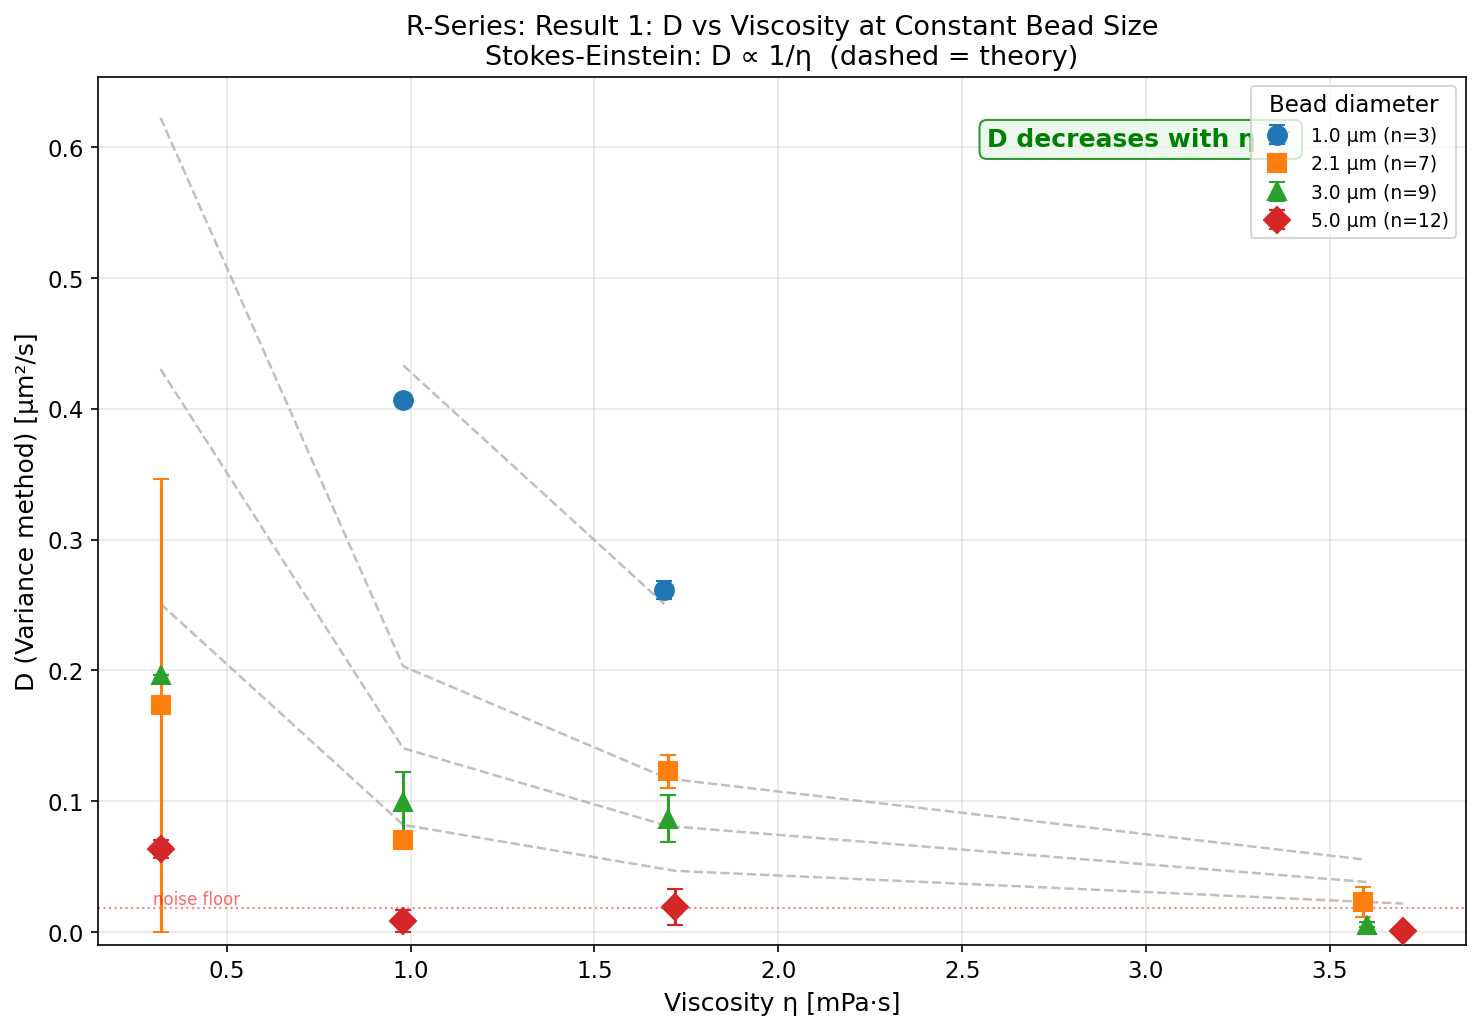

In [5]:
# R-series
plot_D_vs_eta(r_trials, 'R-Series: ',
              os.path.join(R_SESSION, 'D_vs_Viscosity_R-series_ConstantBeadSize.png'))

  Saved: D_vs_Viscosity_S-series_ConstantBeadSize.png


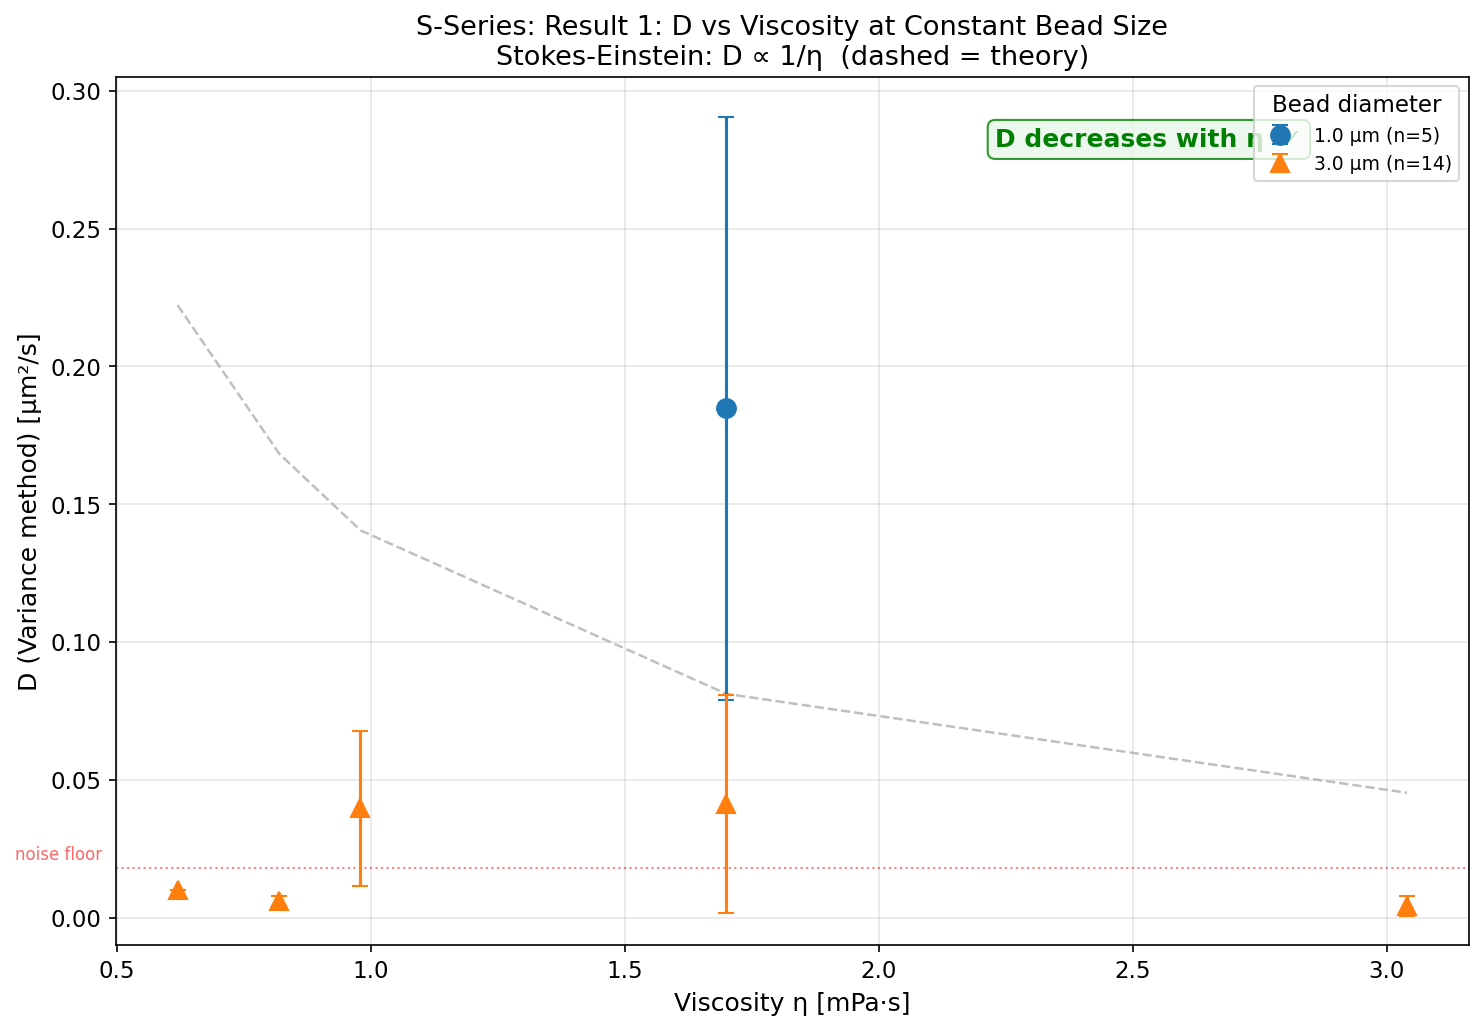

In [6]:
# S-series
plot_D_vs_eta(s_trials, 'S-Series: ',
              os.path.join(S_SESSION, 'D_vs_Viscosity_S-series_ConstantBeadSize.png'))

  Saved: D_vs_Viscosity_Overall_ConstantBeadSize.png


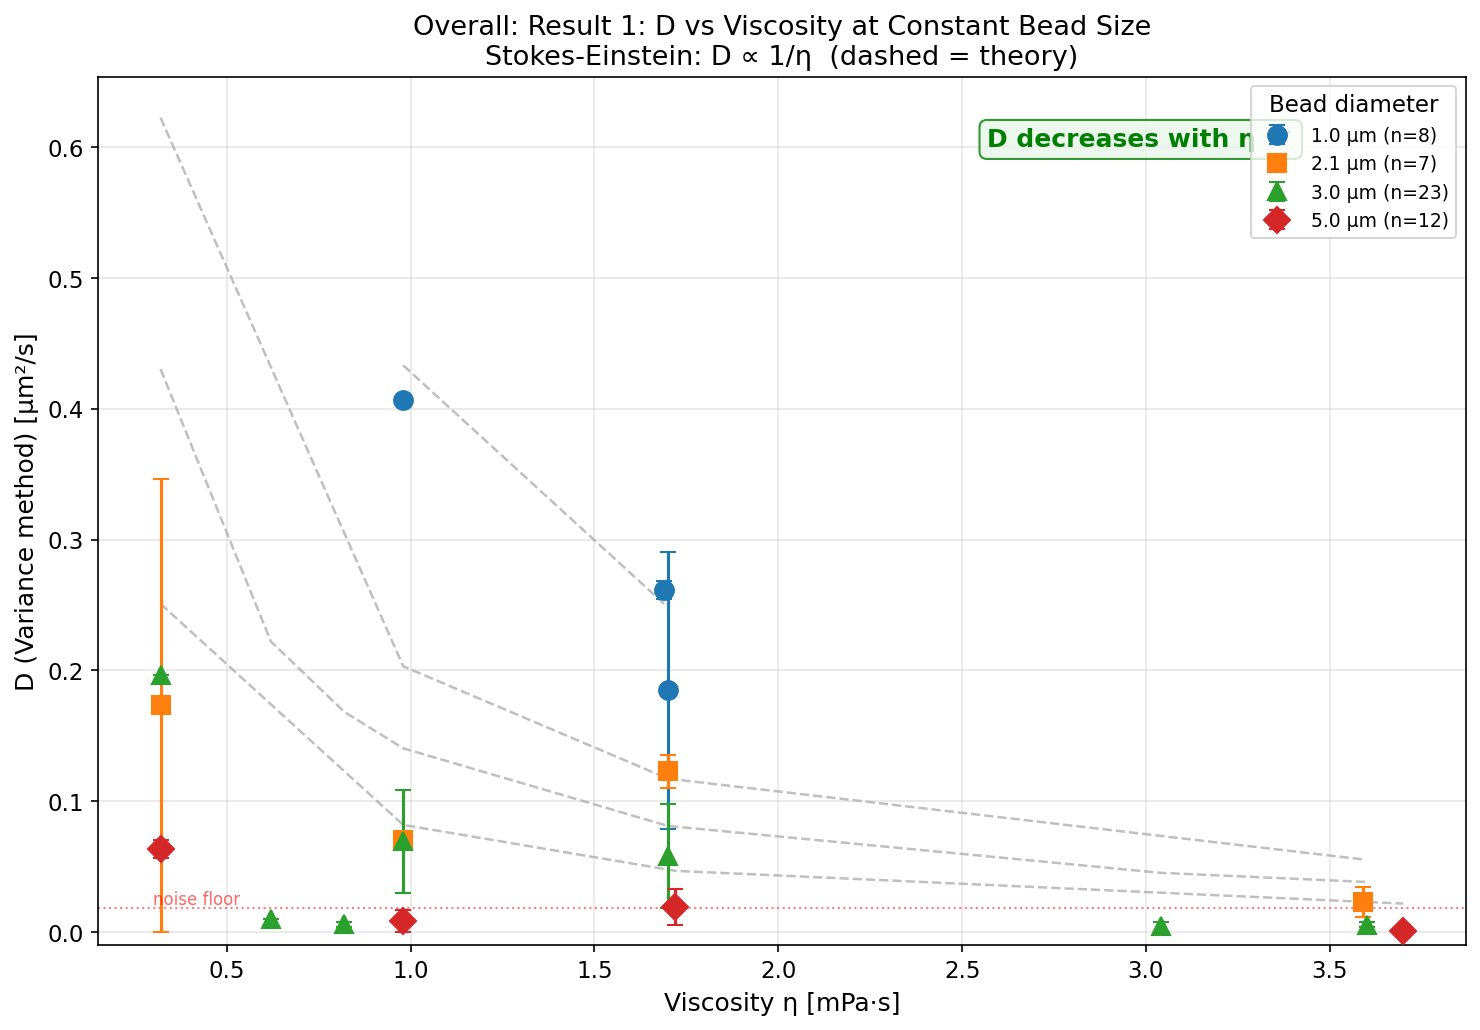

In [7]:
# Overall (R + S combined)
plot_D_vs_eta(all_trials, 'Overall: ',
              os.path.join(SAVE_DIR, 'D_vs_Viscosity_Overall_ConstantBeadSize.png'))

---
## Result 2 — D decreases with increasing bead size (constant viscosity) + α ≈ 1

**Stokes-Einstein:** $D \propto 1/r$ at fixed $\eta$.

**Two panels:**
- **Left:** D vs bead diameter, one curve per solvent. Theory as dashed 1/r curves.
- **Right:** Histogram of MSD exponent α — peak at 1.0 confirms Brownian motion.

In [8]:
def plot_D_vs_bead_and_alpha(trials, title_prefix='', save_path=None):
    """
    RESULT 2: (Left) D vs bead size at constant viscosity.
              (Right) Alpha histogram confirming Brownian motion.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7))
    
    # ── LEFT: D vs bead diameter ──
    solv_groups = group_by(trials, lambda t: t.get('solvent_label', '?'))
    
    for solv in SOLVENT_ORDER:
        if solv not in solv_groups:
            continue
        rows = solv_groups[solv]
        color = SOLVENT_COLORS.get(solv, '#888')
        
        # Group by bead size
        bead_groups = group_by(rows, lambda t: t['bead_um'])
        beads = sorted(bead_groups.keys())
        if len(beads) < 2:
            # Still plot single points
            for b in beads:
                d_vals = [r['D_var'] for r in bead_groups[b]]
                ax1.scatter([b], [np.mean(d_vals)], color=color,
                           marker='o', s=80, zorder=3, alpha=0.7)
            continue
        
        d_means = [np.mean([r['D_var'] for r in bead_groups[b]]) for b in beads]
        d_stds  = [np.std([r['D_var'] for r in bead_groups[b]])
                   if len(bead_groups[b]) > 1 else 0 for b in beads]
        d_theory = [np.mean([r['D_theory_max'] for r in bead_groups[b]]) for b in beads]
        
        # Theory 1/r curve (dashed)
        beads_fine = np.linspace(min(beads) * 0.8, max(beads) * 1.1, 50)
        # Scale theory curve from first point
        D_ref = d_theory[0]
        r_ref = beads[0] / 2
        theory_fine = D_ref * (r_ref / (beads_fine / 2))
        ax1.plot(beads_fine, theory_fine, '--', color=color, lw=1.2, alpha=0.4)
        
        ax1.errorbar(beads, d_means, yerr=d_stds,
                     fmt='o-', color=color, markersize=8, capsize=4, lw=1.5,
                     label=f'{solv} (n={len(rows)})', zorder=3)
    
    ax1.annotate('D decreases with r  ✓', xy=(0.55, 0.92), xycoords='axes fraction',
                 fontsize=12, fontweight='bold', color='green',
                 bbox=dict(boxstyle='round,pad=0.3', fc='#E8F5E9', ec='green', alpha=0.8))
    
    ax1.axhline(y=NOISE_FLOOR, color='red', ls=':', lw=1, alpha=0.5)
    ax1.set_xlabel('Bead Diameter [µm]')
    ax1.set_ylabel('D (Variance method) [µm²/s]')
    ax1.set_title('D vs Bead Size at Constant Viscosity\n'
                  'Stokes-Einstein: D ∝ 1/r  (dashed = 1/r theory)')
    ax1.legend(title='Solvent', fontsize=8)
    ax1.grid(True, alpha=0.3)
    ax1.set_xlim(0, 6)
    ax1.set_ylim(bottom=-0.01)
    
    # ── RIGHT: Alpha histogram ──
    alphas = [t['alpha'] for t in trials if t.get('alpha', 0) > 0.01]
    
    # Color by classification
    a_sub   = [a for a in alphas if a < 0.8]
    a_norm  = [a for a in alphas if 0.8 <= a <= 1.2]
    a_super = [a for a in alphas if a > 1.2]
    
    bins = np.linspace(0, 1.8, 25)
    ax2.hist(a_sub,   bins=bins, alpha=0.7, color='#F44336', label=f'Sub-diffusive (n={len(a_sub)})',
             edgecolor='white', linewidth=0.5)
    ax2.hist(a_norm,  bins=bins, alpha=0.7, color='#4CAF50', label=f'Normal α≈1 (n={len(a_norm)})',
             edgecolor='white', linewidth=0.5)
    ax2.hist(a_super, bins=bins, alpha=0.7, color='#FF9800', label=f'Super-diffusive (n={len(a_super)})',
             edgecolor='white', linewidth=0.5)
    
    ax2.axvline(x=1.0, color='black', ls='-', lw=2.5, label='α = 1 (Brownian)')
    ax2.axvspan(0.8, 1.2, alpha=0.1, color='green')
    
    # Compute and show statistics
    alpha_mean = np.mean(alphas)
    alpha_med  = np.median(alphas)
    pct_normal = len(a_norm) / len(alphas) * 100 if alphas else 0
    
    stats_text = (f'mean α = {alpha_mean:.2f}\n'
                  f'median α = {alpha_med:.2f}\n'
                  f'{pct_normal:.0f}% in [0.8, 1.2]')
    ax2.text(0.02, 0.95, stats_text, transform=ax2.transAxes, fontsize=10,
             verticalalignment='top',
             bbox=dict(boxstyle='round', fc='lightyellow', ec='orange', alpha=0.9))
    
    if pct_normal >= 50:
        ax2.annotate('α ≈ 1 confirmed  ✓', xy=(0.55, 0.92), xycoords='axes fraction',
                     fontsize=12, fontweight='bold', color='green',
                     bbox=dict(boxstyle='round,pad=0.3', fc='#E8F5E9', ec='green', alpha=0.8))
    
    ax2.set_xlabel('MSD Exponent α')
    ax2.set_ylabel('Count')
    ax2.set_title(f'MSD Exponent Distribution (N={len(alphas)})\n'
                  f'α = 1 → pure Brownian diffusion')
    ax2.legend(fontsize=8)
    ax2.grid(True, alpha=0.3)
    
    fig.suptitle(f'{title_prefix}Result 2: D ∝ 1/r  &  α ≈ 1 (Brownian)',
                 fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {os.path.basename(save_path)}')
    plt.show()

  Saved: D_vs_BeadSize_Alpha_R-series_ConstantViscosity.png


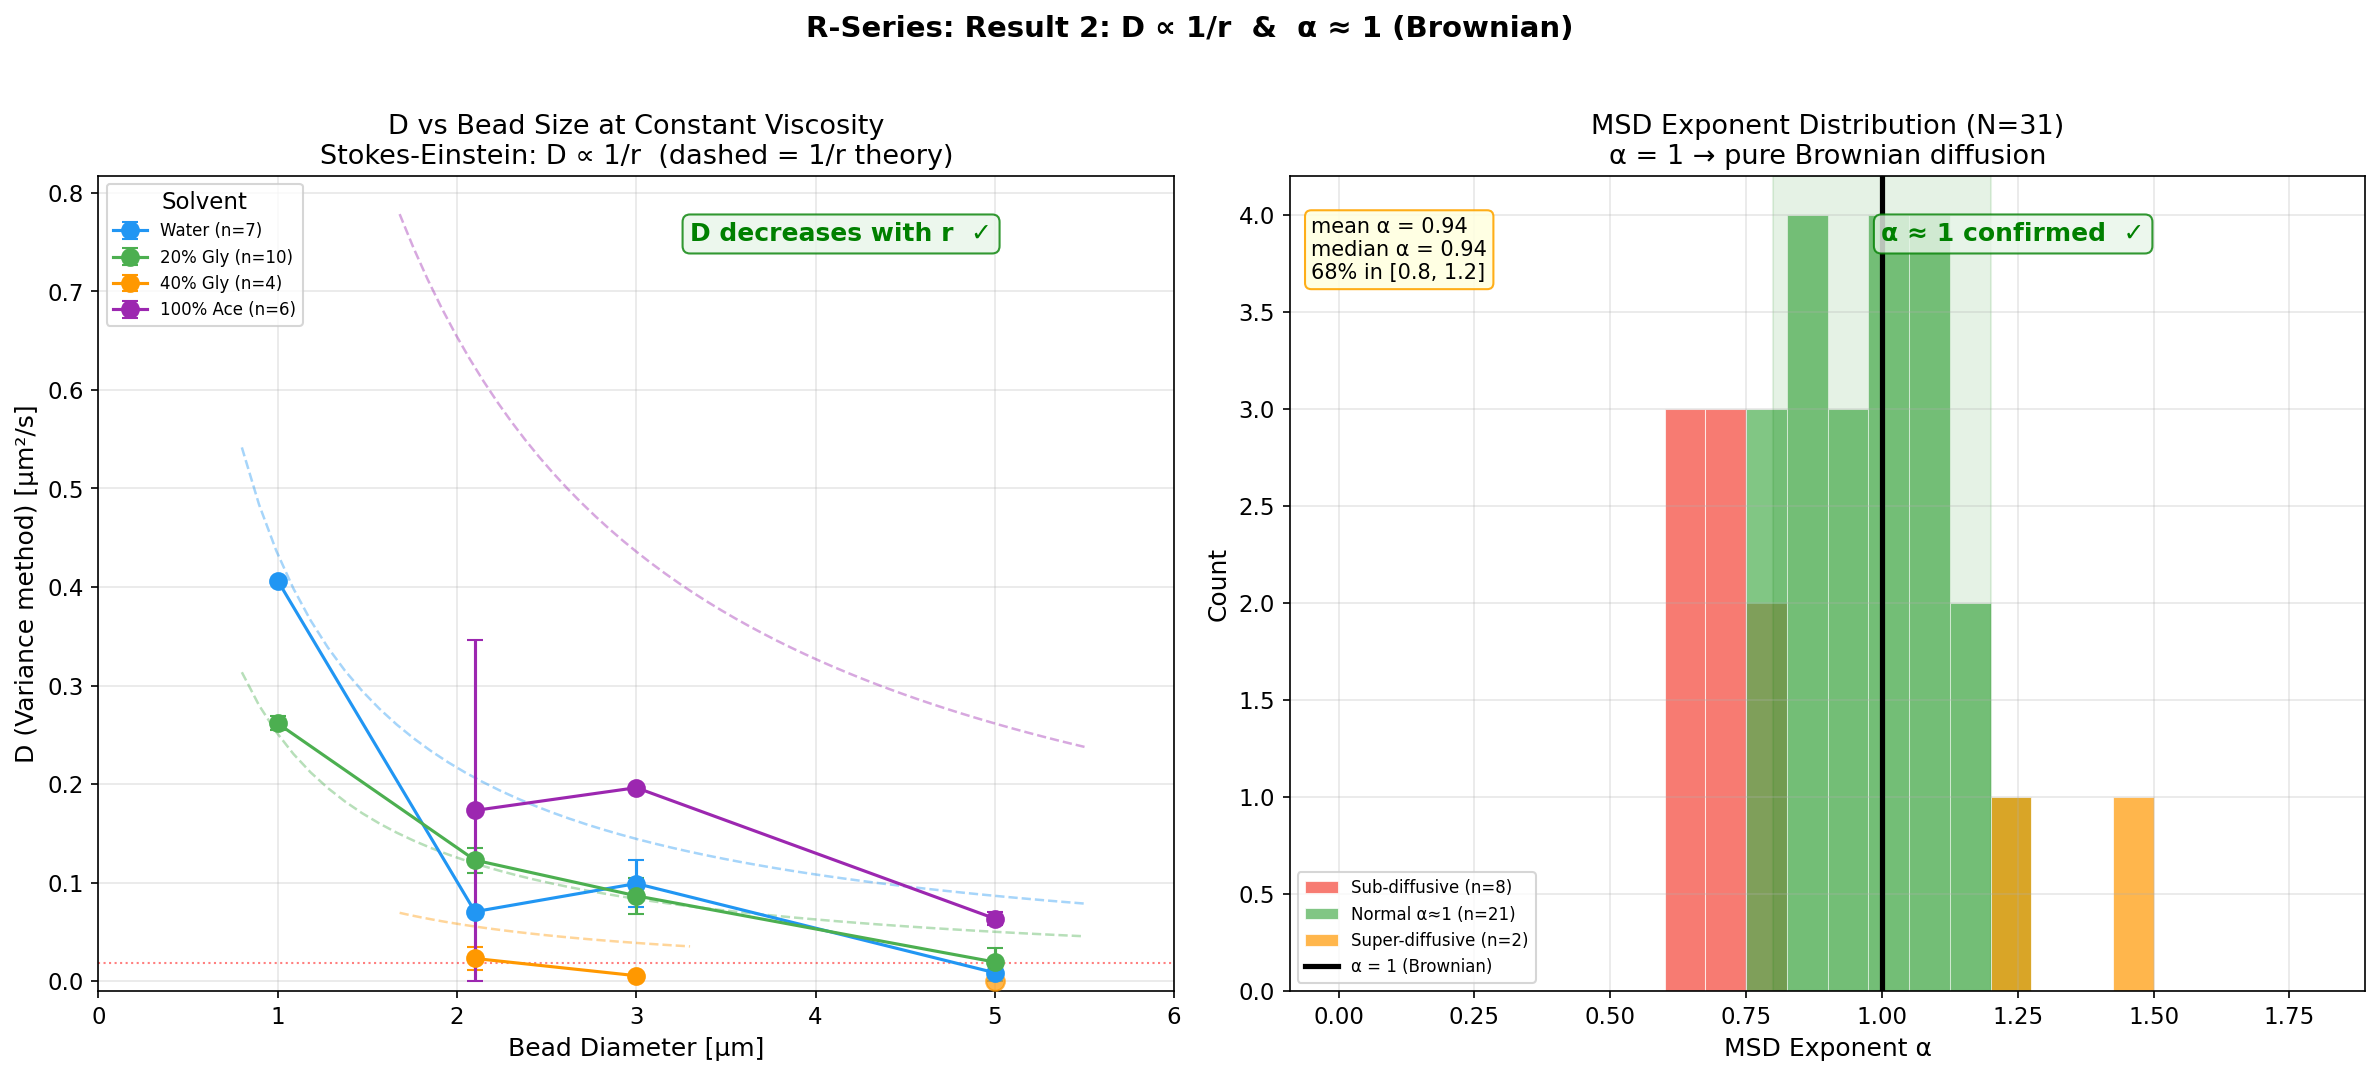

In [9]:
# R-series
plot_D_vs_bead_and_alpha(r_trials, 'R-Series: ',
                         os.path.join(R_SESSION, 'D_vs_BeadSize_Alpha_R-series_ConstantViscosity.png'))

  Saved: D_vs_BeadSize_Alpha_S-series_ConstantViscosity.png


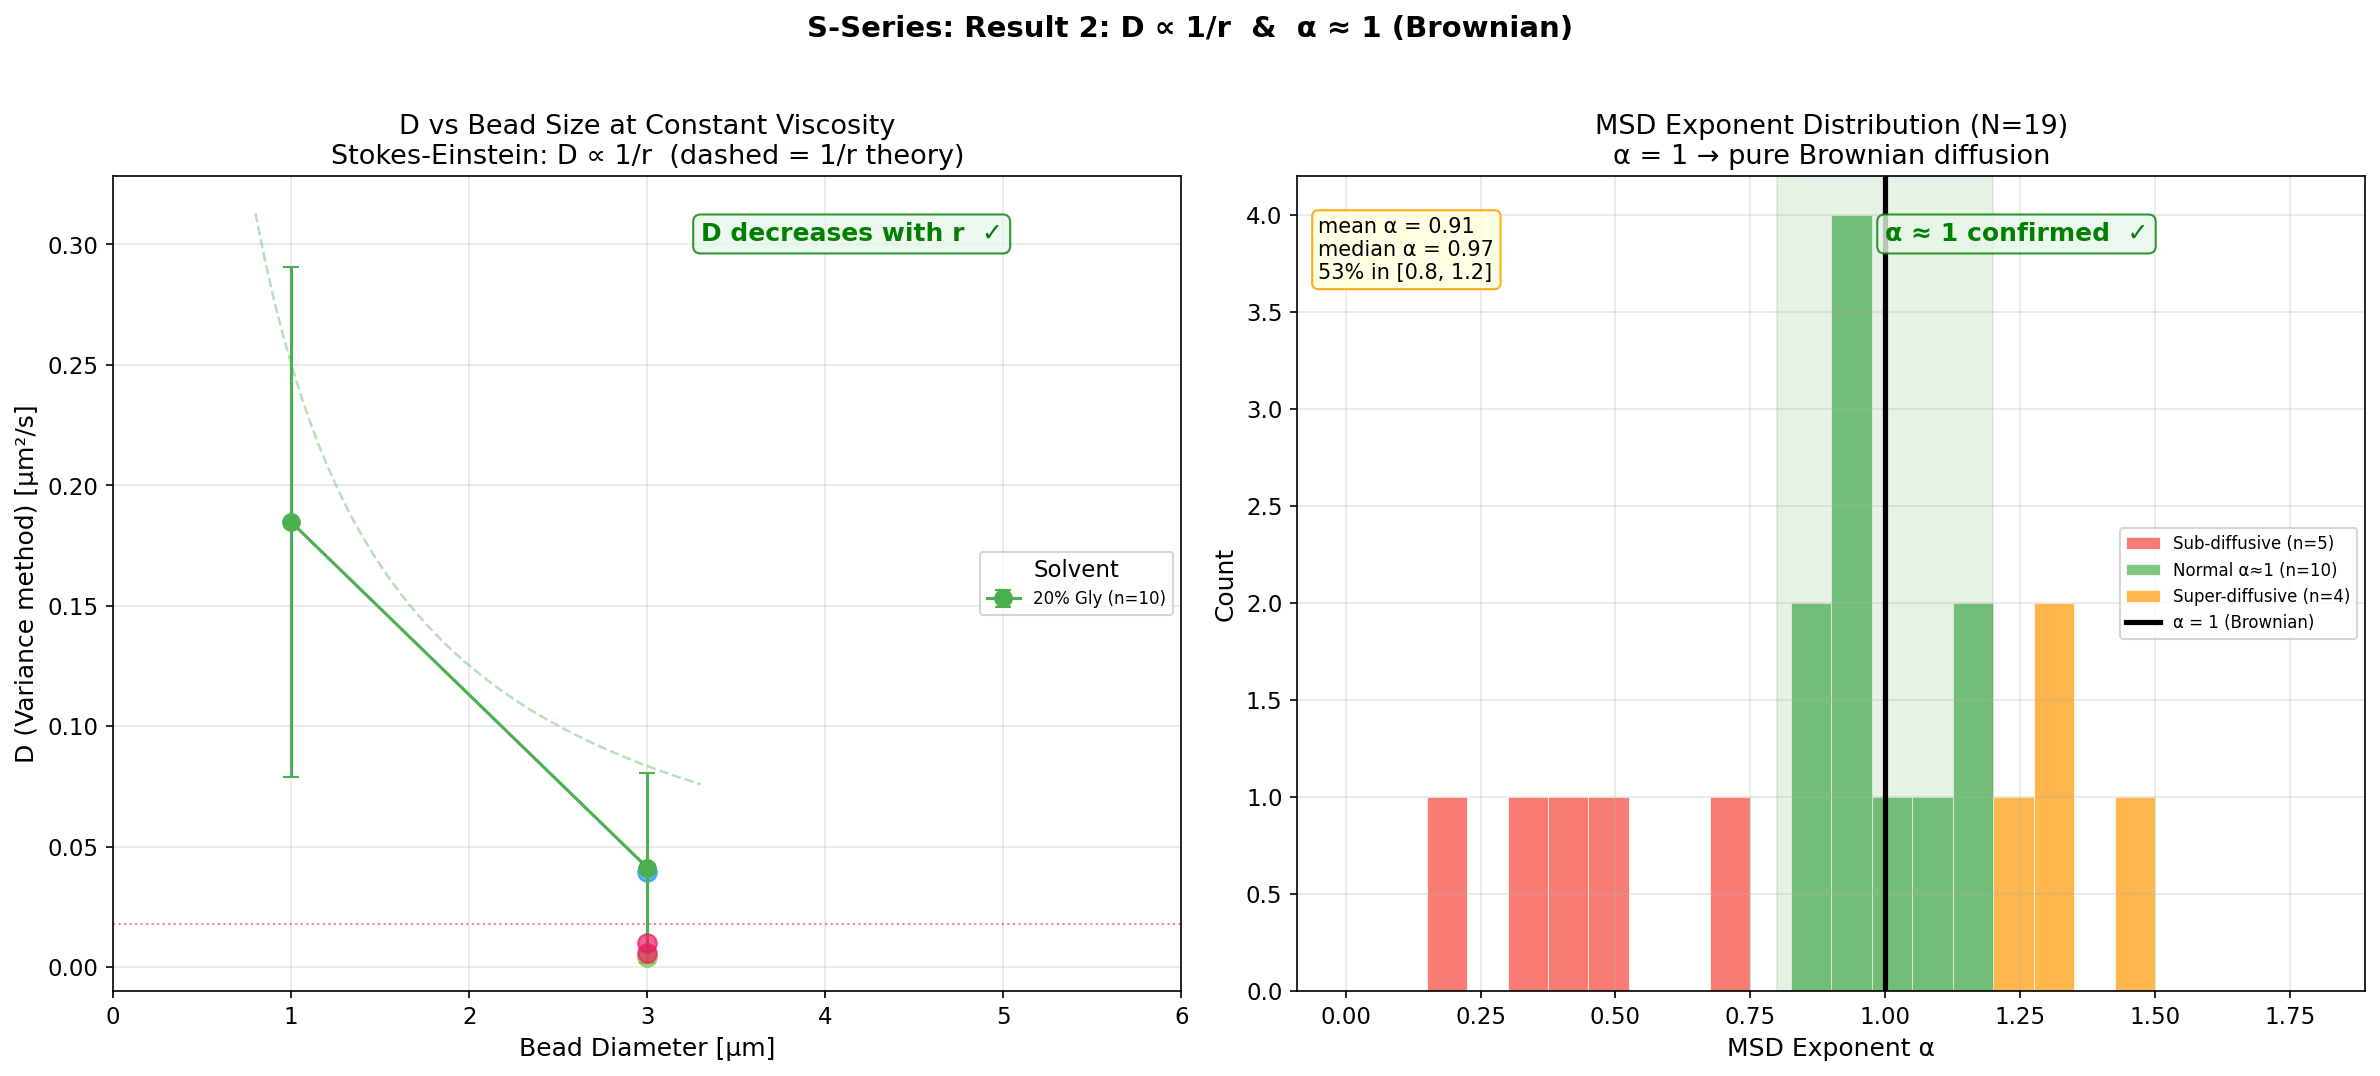

In [10]:
# S-series
plot_D_vs_bead_and_alpha(s_trials, 'S-Series: ',
                         os.path.join(S_SESSION, 'D_vs_BeadSize_Alpha_S-series_ConstantViscosity.png'))

  Saved: D_vs_BeadSize_Alpha_Overall_ConstantViscosity.png


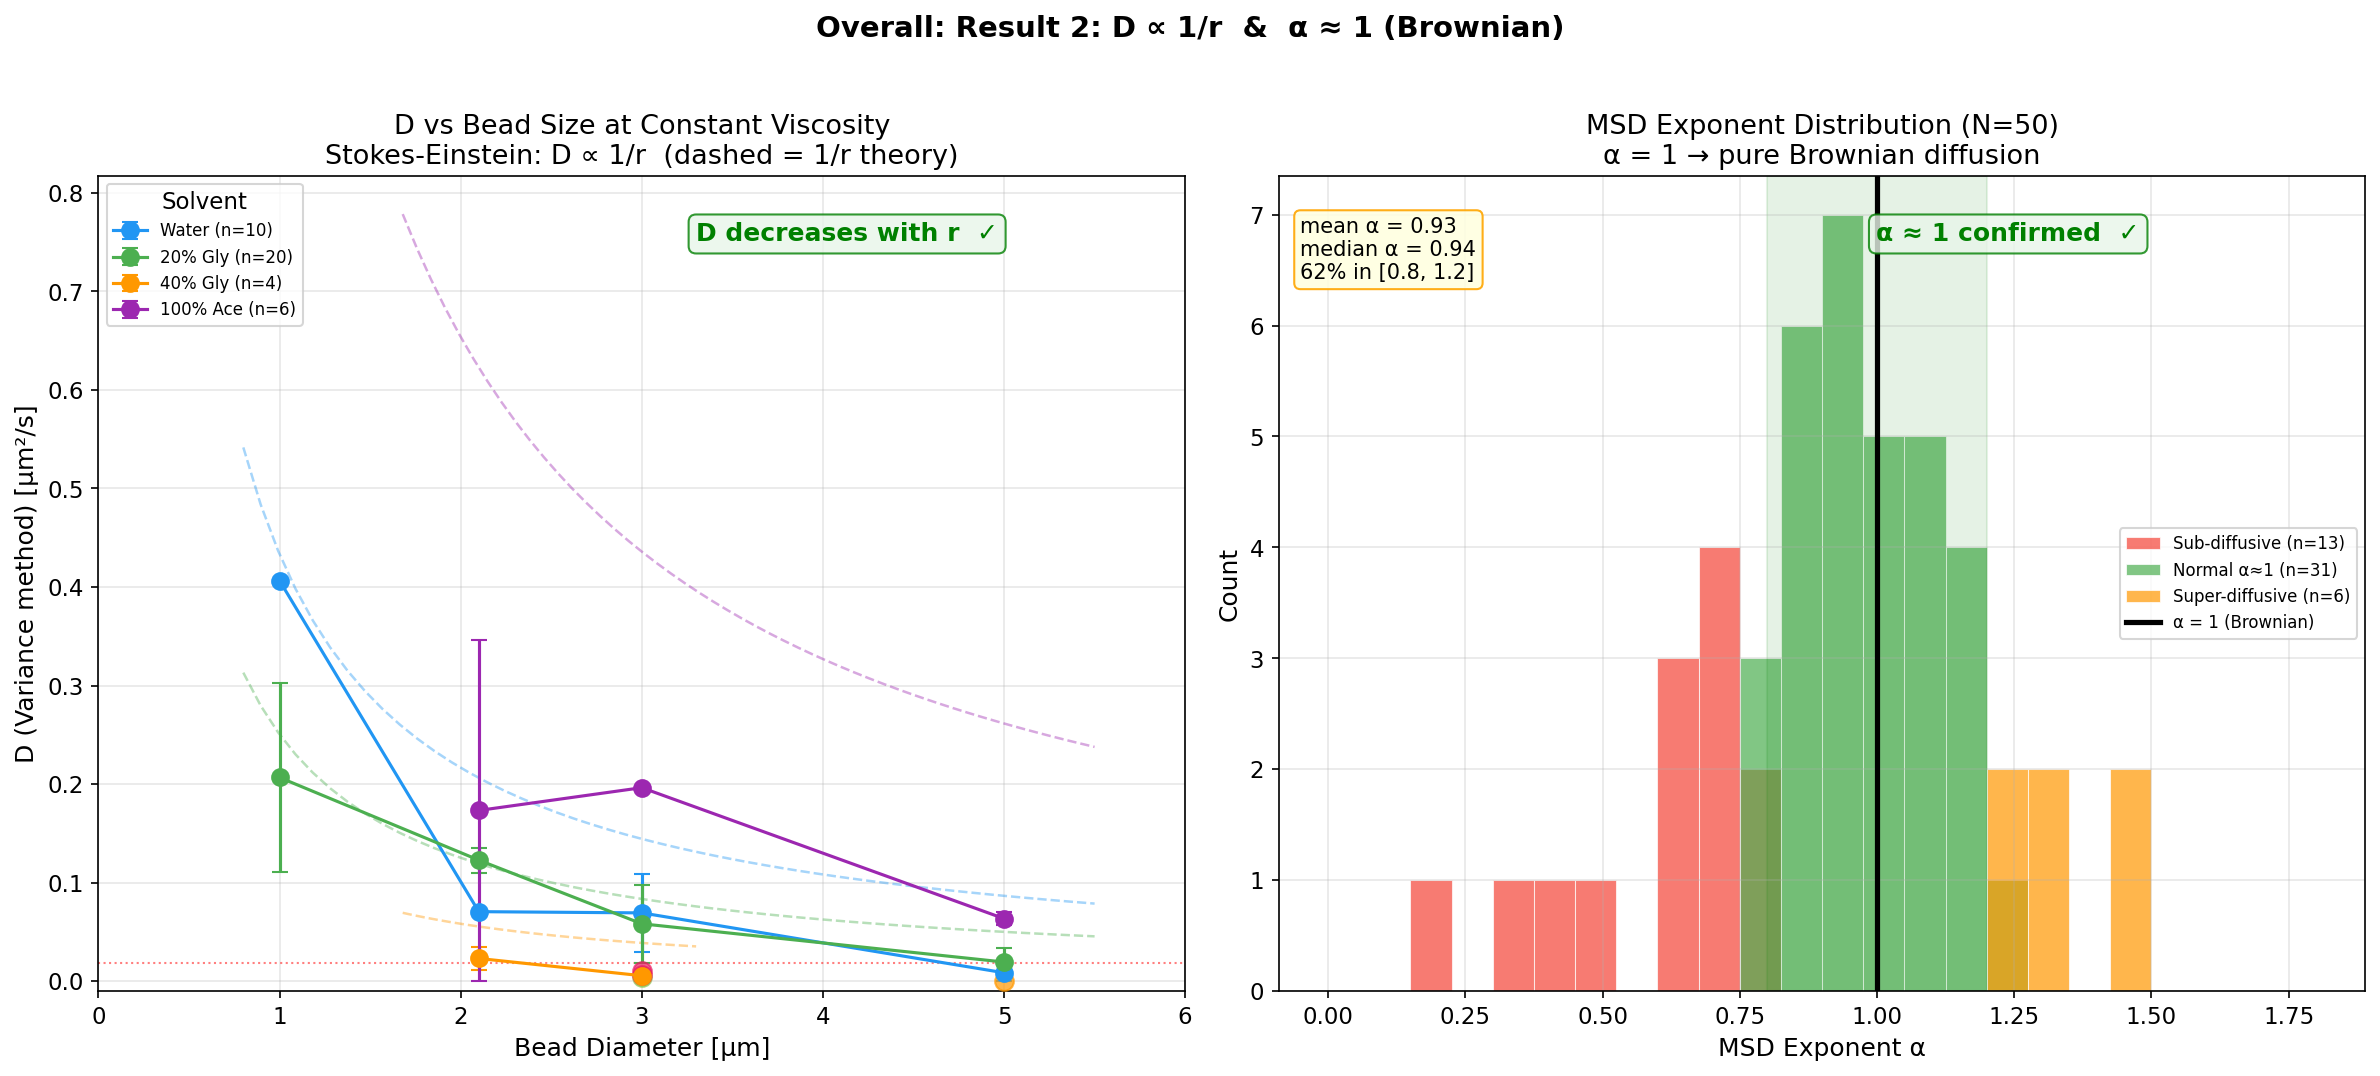

In [11]:
# Overall
plot_D_vs_bead_and_alpha(all_trials, 'Overall: ',
                         os.path.join(SAVE_DIR, 'D_vs_BeadSize_Alpha_Overall_ConstantViscosity.png'))

---
## Result 3 — Log-log D vs η gives slope = −1

**Stokes-Einstein:** $D = k_BT / 6\pi\eta r$

Taking logs: $\log D = -1 \cdot \log\eta + \log(k_BT / 6\pi r)$

So the slope on a log-log plot should be **exactly −1**. We fit each bead-size series
and report the measured slope with uncertainty.

In [12]:
def plot_loglog_D_vs_eta(trials, title_prefix='', save_path=None):
    """
    RESULT 3: Log-log D vs eta with linear regression.
    Expected slope = -1 from Stokes-Einstein.
    Guard: requires >=3 points spanning >=1.5x viscosity range for a valid fit.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 7),
                                    gridspec_kw={'width_ratios': [2, 1]})
    
    # ── LEFT: Log-log scatter + fit ──
    bead_groups = group_by(trials, lambda t: t['bead_um'])
    fit_results = []
    skipped = []
    
    for bead in sorted(bead_groups.keys()):
        rows = bead_groups[bead]
        marker = BEAD_MARKERS.get(bead, 'x')
        ms = BEAD_SIZES.get(bead, 60)
        
        # Get eta and D for each trial (skip D=0 or eta=0)
        etas_all = []
        d_all    = []
        for r in rows:
            eta = r['eta_mPas']
            d   = r['D_var']
            if eta > 0.01 and d > 0.001:  # skip noise-floor hits
                etas_all.append(eta)
                d_all.append(d)
        
        # Guard: need >=3 points AND viscosity range > factor 1.5
        eta_range = max(etas_all) / min(etas_all) if etas_all else 1
        n_distinct_eta = len(set(round(e, 1) for e in etas_all))
        
        if len(etas_all) < 3 or eta_range < 1.5 or n_distinct_eta < 2:
            # Not enough viscosity variation for a meaningful fit
            ax1.scatter(etas_all, d_all, marker=marker, s=ms,
                       edgecolors='black', linewidths=0.5,
                       label=f'{bead} µm (n={len(etas_all)}, no fit — limited η range)',
                       zorder=3, alpha=0.5)
            skipped.append(f'{bead} µm: η range = {eta_range:.1f}x, {n_distinct_eta} distinct η')
            continue
        
        log_eta = np.log10(etas_all)
        log_d   = np.log10(d_all)
        
        # Linear regression on log-log
        slope, intercept, r_value, p_value, std_err = stats.linregress(log_eta, log_d)
        fit_results.append({
            'bead': bead,
            'slope': slope,
            'slope_err': std_err,
            'r_squared': r_value**2,
            'n_points': len(etas_all),
        })
        
        # Plot data
        ax1.scatter(etas_all, d_all, marker=marker, s=ms,
                    edgecolors='black', linewidths=0.5,
                    label=f'{bead} µm: slope={slope:.2f}±{std_err:.2f} (R²={r_value**2:.2f})',
                    zorder=3)
        
        # Plot fit line
        eta_fit = np.linspace(min(log_eta) - 0.1, max(log_eta) + 0.1, 50)
        d_fit = 10**(slope * eta_fit + intercept)
        ax1.plot(10**eta_fit, d_fit, '-', lw=1.5, alpha=0.6, zorder=2)
    
    # Theory reference: slope = -1 line
    eta_ref = np.logspace(-0.6, 0.8, 50)
    kBT = 1.380649e-23 * 295.15
    r_ref = 1.5e-6  # 3 um bead
    D_theory_ref = kBT / (6 * np.pi * eta_ref * 1e-3 * r_ref) * 1e12  # um^2/s
    ax1.plot(eta_ref, D_theory_ref, 'k--', lw=2, alpha=0.3,
             label='slope = −1 (exact Stokes-Einstein, 3µm)')
    
    ax1.set_xscale('log')
    ax1.set_yscale('log')
    ax1.set_xlabel('Viscosity η [mPa·s]')
    ax1.set_ylabel('D (Variance method) [µm²/s]')
    ax1.set_title(f'{title_prefix}Log-Log D vs η\n'
                  f'Stokes-Einstein predicts slope = −1')
    ax1.legend(fontsize=8, loc='lower left')
    ax1.grid(True, alpha=0.3, which='both')
    ax1.axhline(y=NOISE_FLOOR, color='red', ls=':', lw=1, alpha=0.4)
    
    # ── RIGHT: Slope summary bar chart ──
    if fit_results:
        beads_fit  = [f['bead'] for f in fit_results]
        slopes     = [f['slope'] for f in fit_results]
        slope_errs = [f['slope_err'] for f in fit_results]
        
        x_pos = np.arange(len(beads_fit))
        colors = ['#4CAF50' if abs(s + 1) < 0.5 else '#FF9800'
                  for s in slopes]
        
        bars = ax2.barh(x_pos, slopes, xerr=slope_errs, height=0.5,
                        color=colors, capsize=5, edgecolor='black', linewidth=0.5)
        ax2.axvline(x=-1.0, color='red', ls='-', lw=2.5,
                    label='Expected (−1)', zorder=5)
        ax2.axvspan(-1.5, -0.5, alpha=0.08, color='green')
        
        ax2.set_yticks(x_pos)
        ax2.set_yticklabels([f'{b} µm\n(n={f["n_points"]})' for b, f in
                             zip(beads_fit, fit_results)])
        ax2.set_xlabel('Fitted Slope')
        ax2.set_title('Power-law Exponent\n(expected = −1)')
        ax2.legend(fontsize=9)
        ax2.grid(True, alpha=0.3, axis='x')
        ax2.set_xlim(-3, 1)
        
        for i, f in enumerate(fit_results):
            ax2.text(f['slope'] - 0.15, i, f'{f["slope"]:.2f}±{f["slope_err"]:.2f}',
                     va='center', ha='right', fontsize=9, fontweight='bold')
        
        mean_slope = np.mean(slopes)
        if abs(mean_slope + 1) < 0.5:
            ax2.annotate(f'mean slope = {mean_slope:.2f}  ✓',
                         xy=(0.05, 0.05), xycoords='axes fraction',
                         fontsize=11, fontweight='bold', color='green',
                         bbox=dict(boxstyle='round,pad=0.3', fc='#E8F5E9',
                                   ec='green', alpha=0.8))
    else:
        ax2.text(0.5, 0.5, 'Insufficient viscosity\nvariation for fit\n\n'
                 '(need ≥3 points spanning\n≥1.5× η range)',
                 transform=ax2.transAxes,
                 ha='center', va='center', fontsize=12, color='gray',
                 bbox=dict(boxstyle='round', fc='#FFF3E0', ec='orange', alpha=0.8))
    
    fig.suptitle(f'{title_prefix}Result 3: Log-log slope = −1 (Power Law)',
                 fontsize=14, fontweight='bold', y=1.02)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {os.path.basename(save_path)}')
    plt.show()
    
    # Print fit summary
    if fit_results:
        print(f'\n  Fit Summary ({title_prefix.strip()}):')
        print(f'  {"Bead":>6}  {"Slope":>8}  {"±err":>6}  {"R²":>6}  {"N":>3}')
        for f in fit_results:
            match = '  ✓' if abs(f['slope'] + 1) < 0.5 else '  ✗'
            print(f'  {f["bead"]:>5.1f}µm  {f["slope"]:>+8.3f}  {f["slope_err"]:>6.3f}  '
                  f'{f["r_squared"]:>6.3f}  {f["n_points"]:>3}{match}')
    if skipped:
        print(f'\n  Skipped (insufficient η range):')
        for s in skipped:
            print(f'    {s}')

  Saved: LogLog_Slope_R-series_D_vs_Viscosity_PowerLaw.png


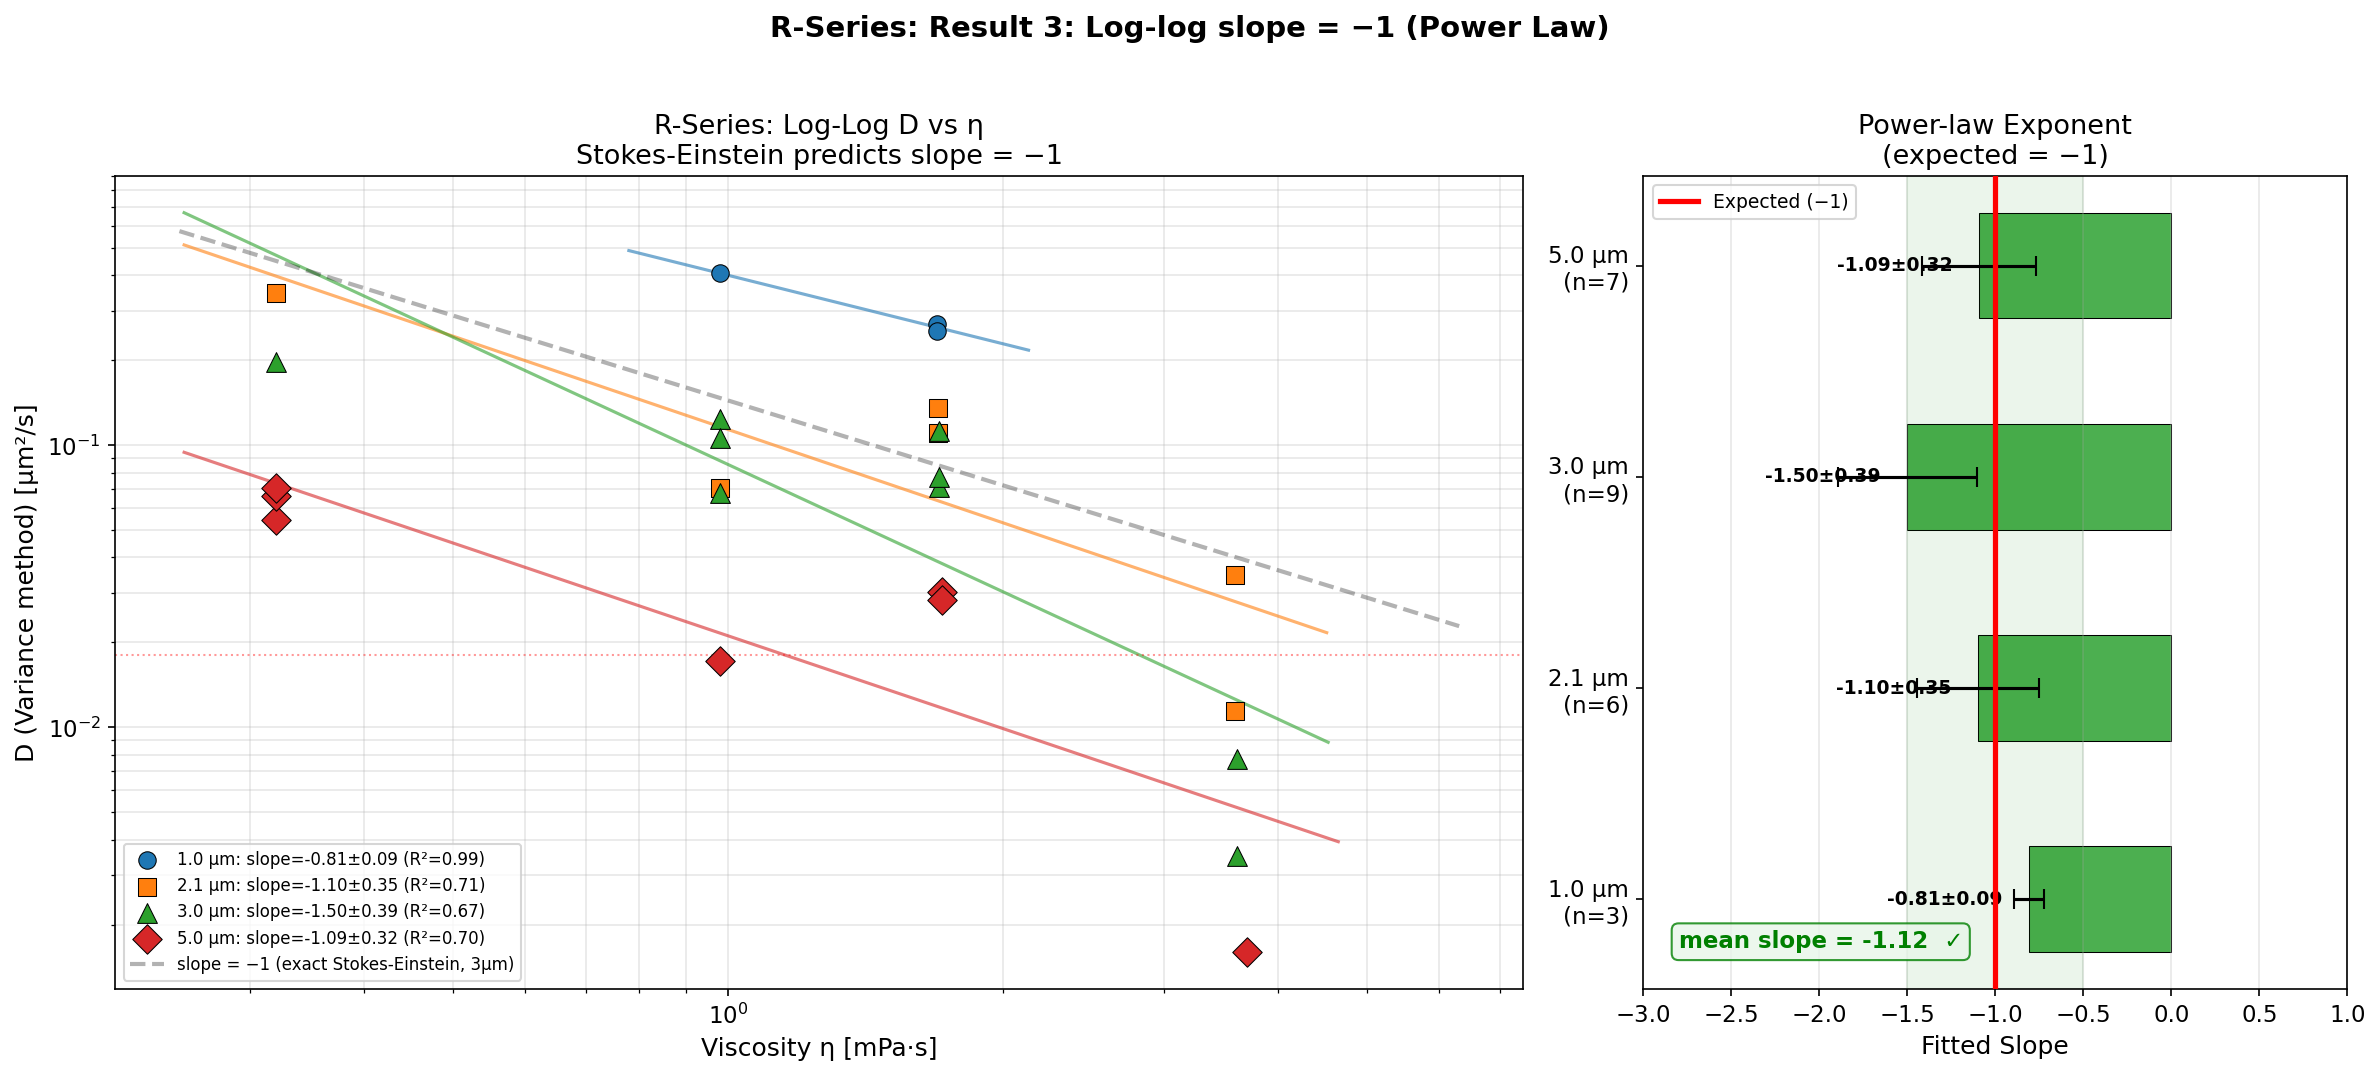


  Fit Summary (R-Series:):
    Bead     Slope    ±err      R²    N
    1.0µm    -0.807   0.087   0.989    3  ✓
    2.1µm    -1.099   0.348   0.714    6  ✓
    3.0µm    -1.500   0.394   0.675    9  ✓
    5.0µm    -1.093   0.323   0.696    7  ✓


In [13]:
# R-series
plot_loglog_D_vs_eta(r_trials, 'R-Series: ',
                     os.path.join(R_SESSION, 'LogLog_Slope_R-series_D_vs_Viscosity_PowerLaw.png'))

  Saved: LogLog_Slope_S-series_D_vs_Viscosity_PowerLaw.png


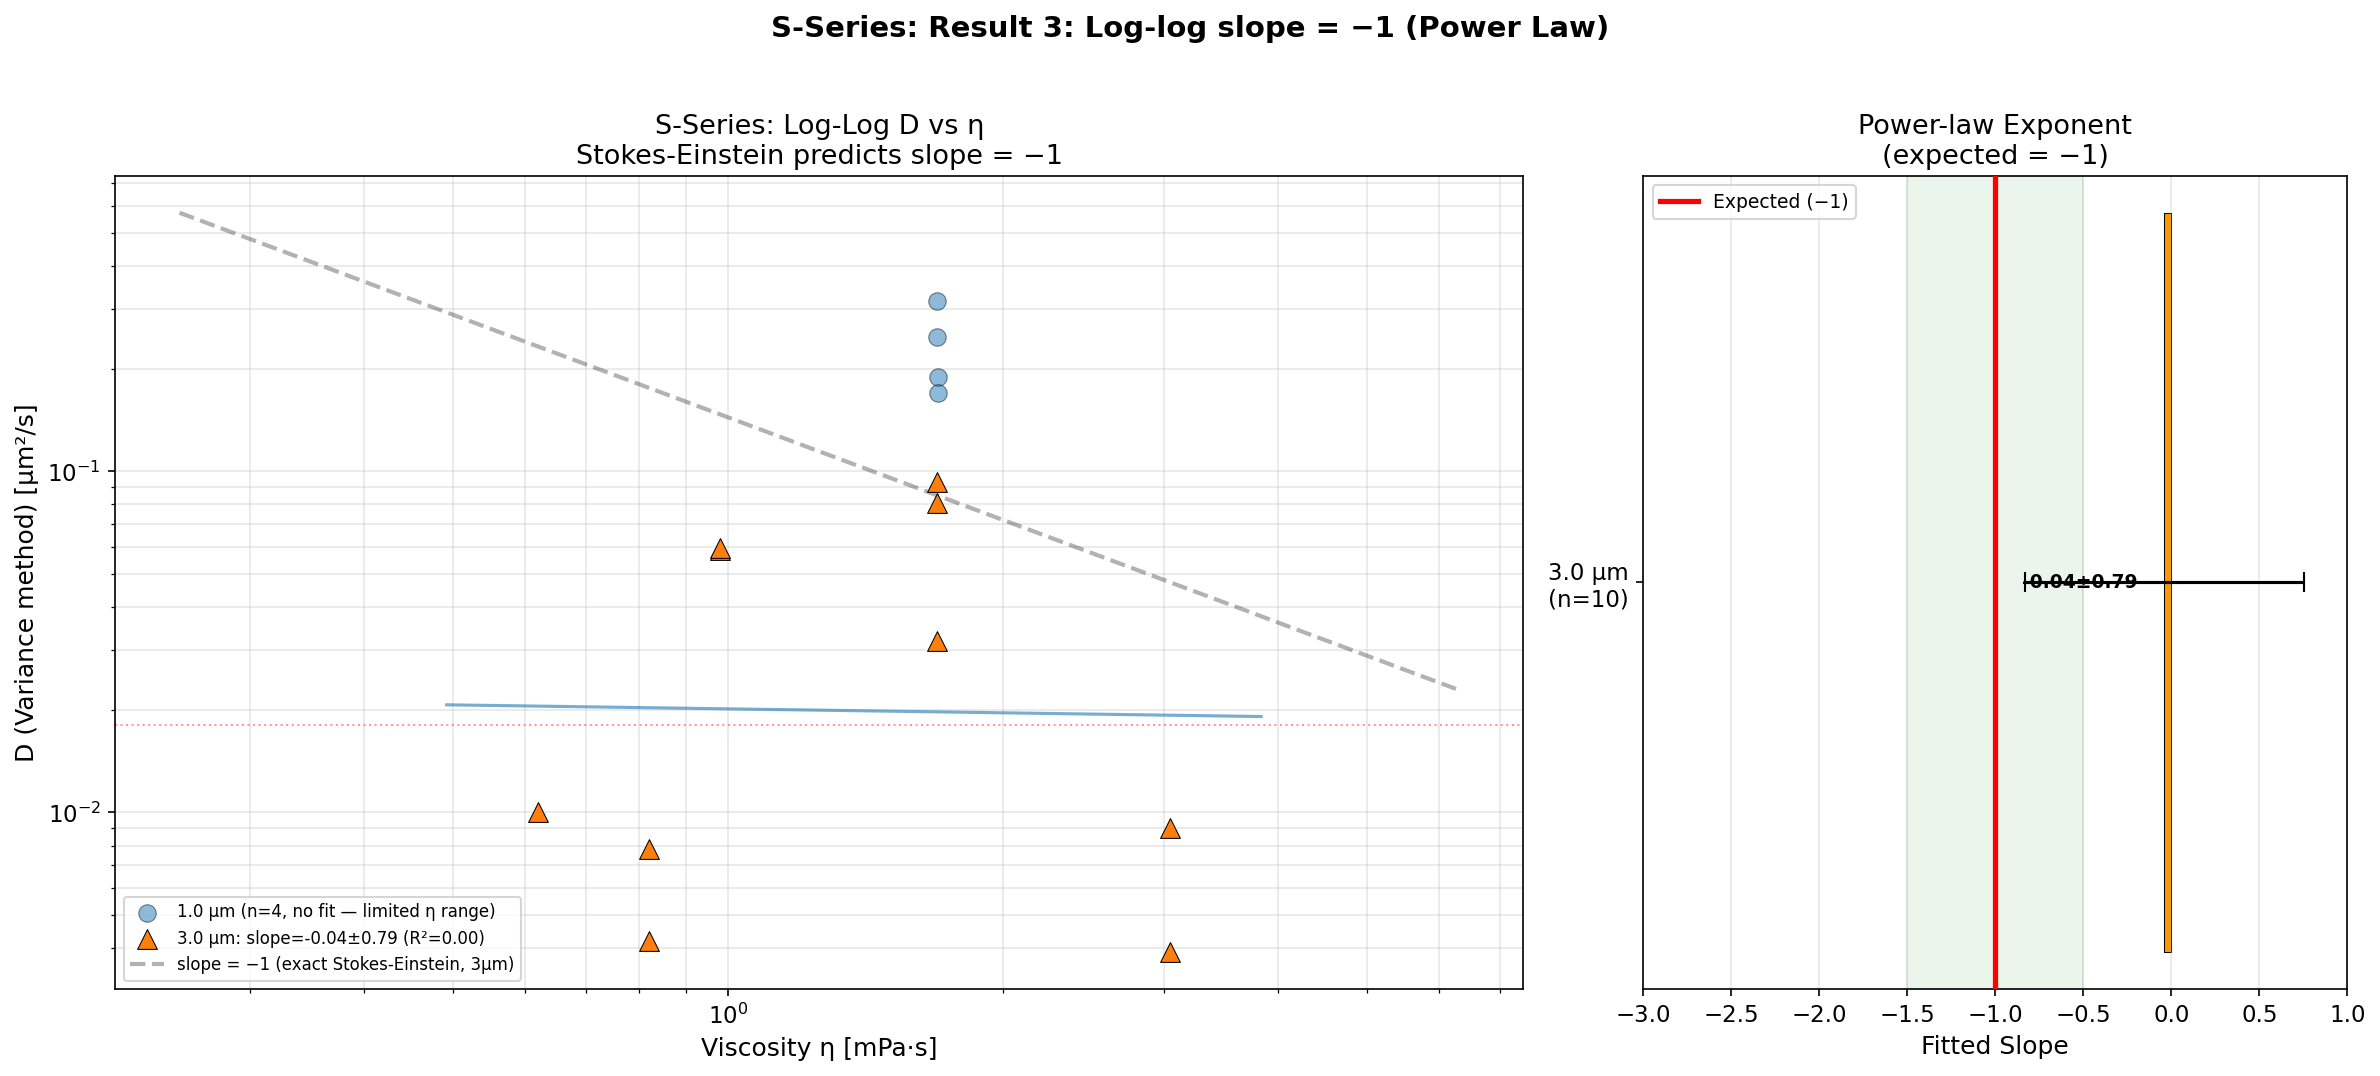


  Fit Summary (S-Series:):
    Bead     Slope    ±err      R²    N
    3.0µm    -0.039   0.793   0.000   10  ✗

  Skipped (insufficient η range):
    1.0 µm: η range = 1.0x, 1 distinct η


In [14]:
# S-series
plot_loglog_D_vs_eta(s_trials, 'S-Series: ',
                     os.path.join(S_SESSION, 'LogLog_Slope_S-series_D_vs_Viscosity_PowerLaw.png'))

  Saved: LogLog_Slope_Overall_D_vs_Viscosity_PowerLaw.png


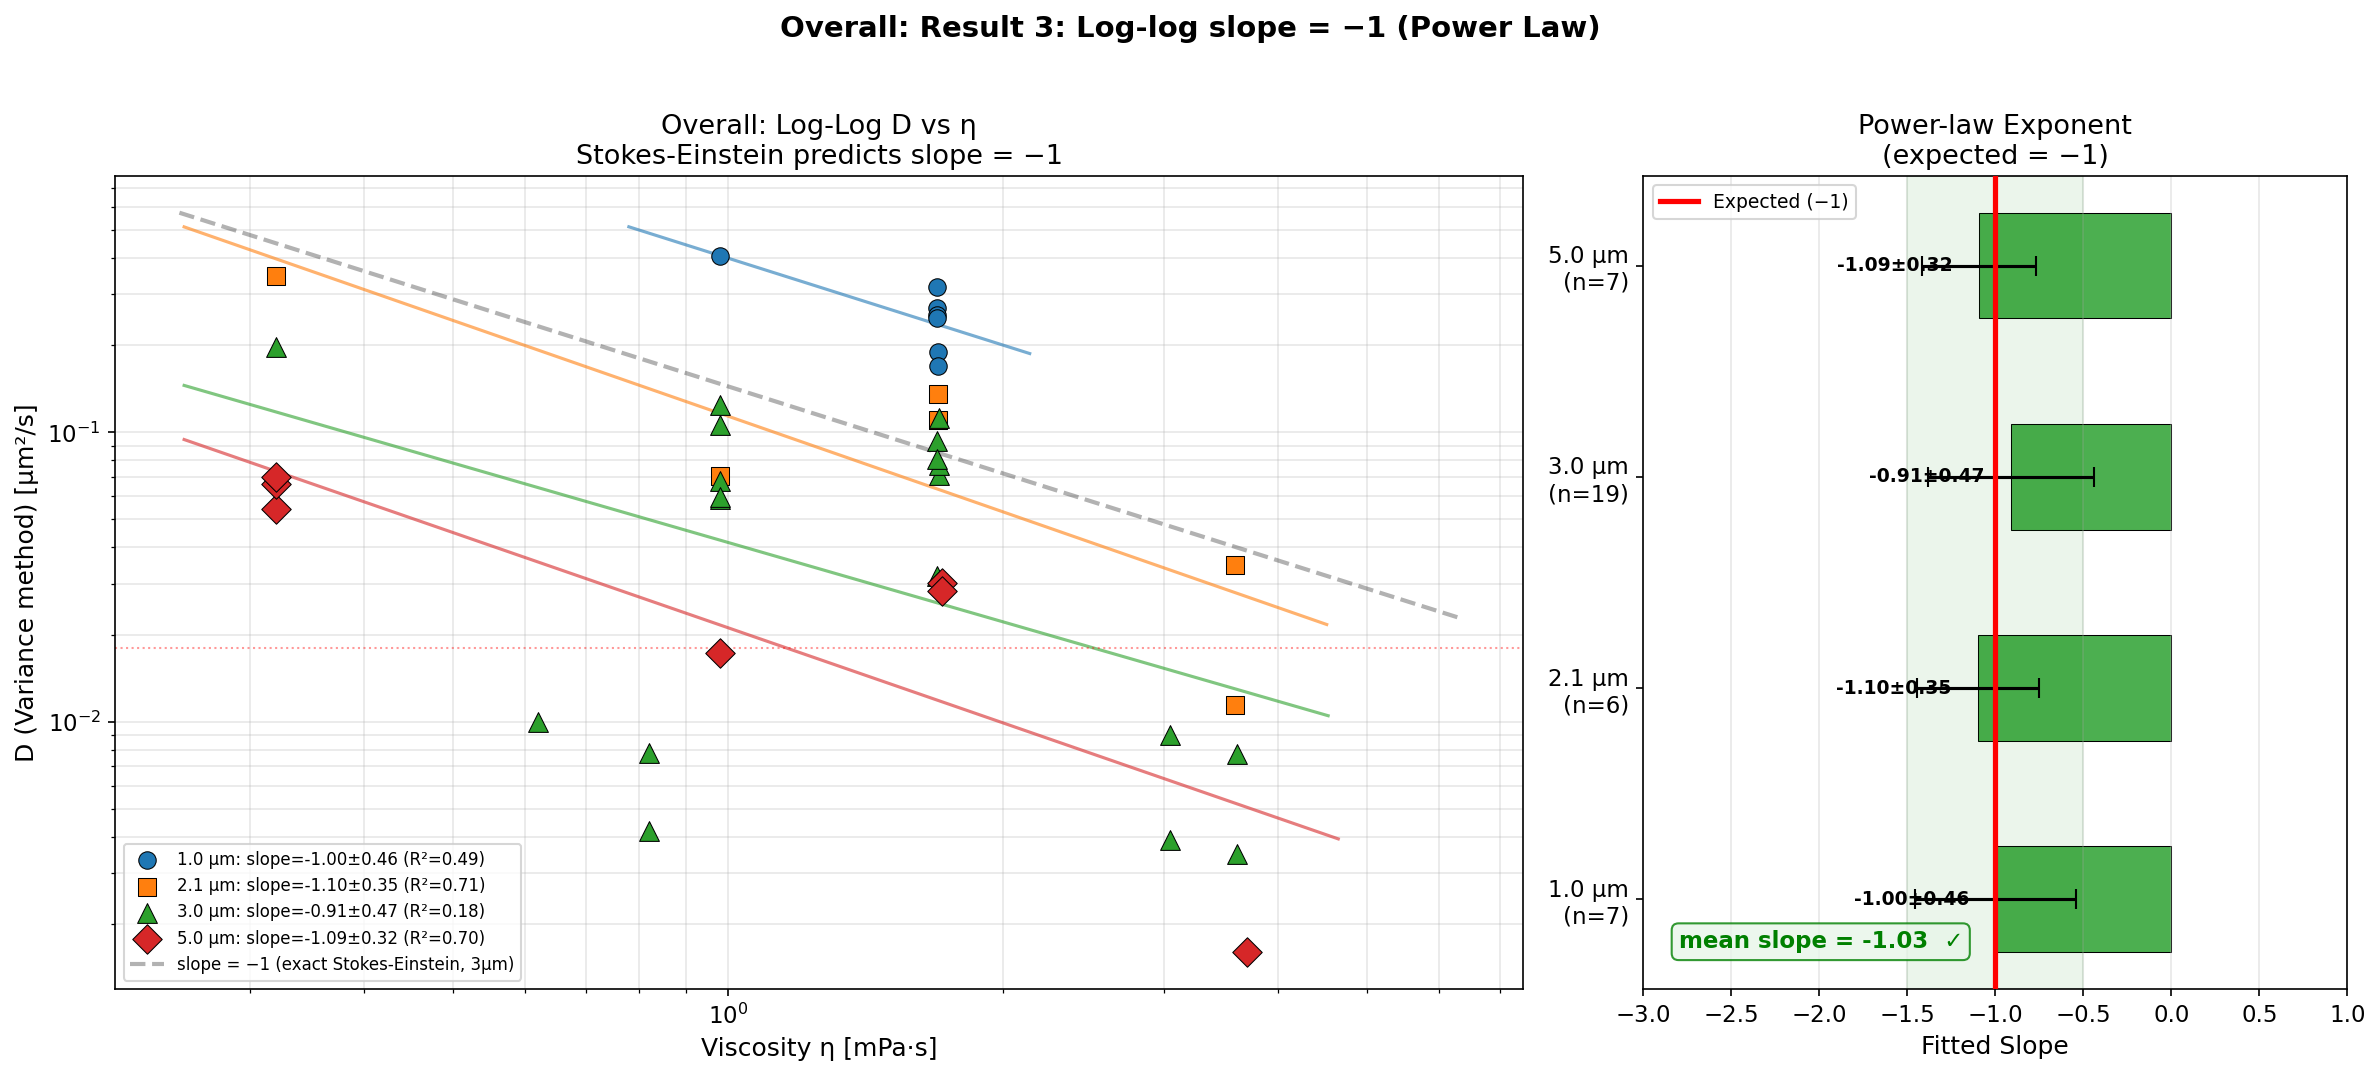


  Fit Summary (Overall:):
    Bead     Slope    ±err      R²    N
    1.0µm    -0.999   0.456   0.490    7  ✓
    2.1µm    -1.099   0.348   0.714    6  ✓
    3.0µm    -0.912   0.470   0.181   19  ✓
    5.0µm    -1.093   0.323   0.696    7  ✓


In [15]:
# Overall
plot_loglog_D_vs_eta(all_trials, 'Overall: ',
                     os.path.join(SAVE_DIR, 'LogLog_Slope_Overall_D_vs_Viscosity_PowerLaw.png'))

---
## Combined Summary — All Three Results in One Figure

A single 3-panel figure for each dataset (R, S, Overall) combining all three physics results.

In [16]:
def plot_combined_3results(trials, title_prefix='', save_path=None):
    """
    Combined 3-panel: (1) D vs eta, (2) D vs bead + alpha, (3) log-log slope.
    Guard: requires >=3 points spanning >=1.5x viscosity range for a valid fit.
    """
    fig = plt.figure(figsize=(20, 6.5))
    gs = fig.add_gridspec(1, 4, width_ratios=[1, 1, 1.2, 0.6], wspace=0.35)
    ax1 = fig.add_subplot(gs[0])
    ax2 = fig.add_subplot(gs[1])
    ax3 = fig.add_subplot(gs[2])
    ax4 = fig.add_subplot(gs[3])
    
    # ── Panel 1: D vs eta ──
    bead_groups = group_by(trials, lambda t: t['bead_um'])
    for bead in sorted(bead_groups.keys()):
        rows = bead_groups[bead]
        marker = BEAD_MARKERS.get(bead, 'x')
        eta_groups = group_by(rows, lambda t: round(t['eta_mPas'], 2))
        etas = sorted(eta_groups.keys())
        d_means = [np.mean([r['D_var'] for r in eta_groups[e]]) for e in etas]
        d_theory = [np.mean([r['D_theory_max'] for r in eta_groups[e]]) for e in etas]
        ax1.plot(etas, d_theory, '--', color='gray', lw=1, alpha=0.4)
        ax1.plot(etas, d_means, marker=marker, markersize=7, lw=1.2,
                 label=f'{bead} µm')
    ax1.axhline(y=NOISE_FLOOR, color='red', ls=':', lw=0.8, alpha=0.4)
    ax1.set_xlabel('η [mPa·s]')
    ax1.set_ylabel('D [µm²/s]')
    ax1.set_title('(1) D vs η\nD ∝ 1/η', fontsize=11)
    ax1.legend(fontsize=7)
    ax1.grid(True, alpha=0.3)
    ax1.set_ylim(bottom=-0.01)
    
    # ── Panel 2: D vs bead size ──
    solv_groups = group_by(trials, lambda t: t.get('solvent_label', '?'))
    for solv in SOLVENT_ORDER:
        if solv not in solv_groups:
            continue
        rows = solv_groups[solv]
        color = SOLVENT_COLORS.get(solv, '#888')
        bg = group_by(rows, lambda t: t['bead_um'])
        beads = sorted(bg.keys())
        if len(beads) < 2:
            continue
        d_means = [np.mean([r['D_var'] for r in bg[b]]) for b in beads]
        ax2.plot(beads, d_means, 'o-', color=color, markersize=7, lw=1.2,
                 label=solv)
    ax2.axhline(y=NOISE_FLOOR, color='red', ls=':', lw=0.8, alpha=0.4)
    ax2.set_xlabel('Bead diameter [µm]')
    ax2.set_ylabel('D [µm²/s]')
    ax2.set_title('(2) D vs bead size\nD ∝ 1/r', fontsize=11)
    ax2.legend(fontsize=7)
    ax2.grid(True, alpha=0.3)
    ax2.set_xlim(0, 6)
    ax2.set_ylim(bottom=-0.01)
    
    # ── Panel 3: Log-log with fits (GUARDED) ──
    fit_results = []
    skipped_combined = []
    for bead in sorted(bead_groups.keys()):
        rows = bead_groups[bead]
        marker = BEAD_MARKERS.get(bead, 'x')
        etas = [r['eta_mPas'] for r in rows if r['eta_mPas'] > 0.01 and r['D_var'] > 0.001]
        ds   = [r['D_var'] for r in rows if r['eta_mPas'] > 0.01 and r['D_var'] > 0.001]
        
        # Guard: need >=3 points AND viscosity range > factor 1.5 AND >=2 distinct eta
        eta_range = max(etas) / min(etas) if etas else 1
        n_distinct_eta = len(set(round(e, 1) for e in etas))
        
        if len(etas) < 3 or eta_range < 1.5 or n_distinct_eta < 2:
            # Plot points without fit
            if etas:
                ax3.scatter(etas, ds, marker=marker, s=50, edgecolors='black',
                            linewidths=0.4, zorder=3, alpha=0.4,
                            label=f'{bead}µm (no fit)')
            skipped_combined.append(f'{bead}µm: η range={eta_range:.1f}x, {n_distinct_eta} distinct')
            continue
        
        ax3.scatter(etas, ds, marker=marker, s=50, edgecolors='black',
                    linewidths=0.4, zorder=3)
        slope, intercept, r_val, _, std_err = stats.linregress(
            np.log10(etas), np.log10(ds))
        fit_results.append({'bead': bead, 'slope': slope, 'err': std_err,
                            'r2': r_val**2, 'n': len(etas)})
        eta_fit = np.logspace(np.log10(min(etas)) - 0.1, np.log10(max(etas)) + 0.1, 50)
        ax3.plot(eta_fit, 10**(slope * np.log10(eta_fit) + intercept),
                 '-', lw=1.5, alpha=0.6, label=f'{bead}µm: m={slope:.2f}')
    
    ax3.set_xscale('log')
    ax3.set_yscale('log')
    ax3.axhline(y=NOISE_FLOOR, color='red', ls=':', lw=0.8, alpha=0.4)
    ax3.set_xlabel('η [mPa·s]')
    ax3.set_ylabel('D [µm²/s]')
    ax3.set_title('(3) Log-log D vs η\nSlope = −1?', fontsize=11)
    ax3.legend(fontsize=7)
    ax3.grid(True, alpha=0.3, which='both')
    
    # ── Panel 4: Slope summary ──
    if fit_results:
        beads_f = [f['bead'] for f in fit_results]
        slopes  = [f['slope'] for f in fit_results]
        errs    = [f['err'] for f in fit_results]
        colors  = ['#4CAF50' if abs(s + 1) < 0.5 else '#FF9800' for s in slopes]
        y_pos = np.arange(len(beads_f))
        ax4.barh(y_pos, slopes, xerr=errs, height=0.5,
                 color=colors, capsize=4, edgecolor='black', linewidth=0.5)
        ax4.axvline(x=-1.0, color='red', ls='-', lw=2.5)
        ax4.set_yticks(y_pos)
        ax4.set_yticklabels([f'{b}µm' for b in beads_f], fontsize=9)
        ax4.set_xlabel('Slope')
        ax4.set_title('Exponent\n(exp.=−1)', fontsize=10)
        ax4.set_xlim(-3, 1)
        ax4.grid(True, alpha=0.3, axis='x')
        for i, f in enumerate(fit_results):
            ax4.text(max(f['slope'] - 0.1, -2.9), i,
                     f'{f["slope"]:+.2f}', va='center', ha='right',
                     fontsize=8, fontweight='bold')
    else:
        ax4.text(0.5, 0.5, 'No valid fits\n(limited η range)',
                 transform=ax4.transAxes, ha='center', va='center',
                 fontsize=10, color='gray',
                 bbox=dict(boxstyle='round', fc='#FFF3E0', ec='orange', alpha=0.8))
    
    fig.suptitle(f'{title_prefix}Physics Verification: Stokes-Einstein D = kT/6πηr',
                 fontsize=14, fontweight='bold', y=1.04)
    fig.tight_layout()
    if save_path:
        fig.savefig(save_path, dpi=200, bbox_inches='tight')
        print(f'  Saved: {os.path.basename(save_path)}')
    if skipped_combined:
        print(f'  Skipped fits: {", ".join(skipped_combined)}')
    plt.show()

  Saved: Combined_PhysicsVerification_R-series.png


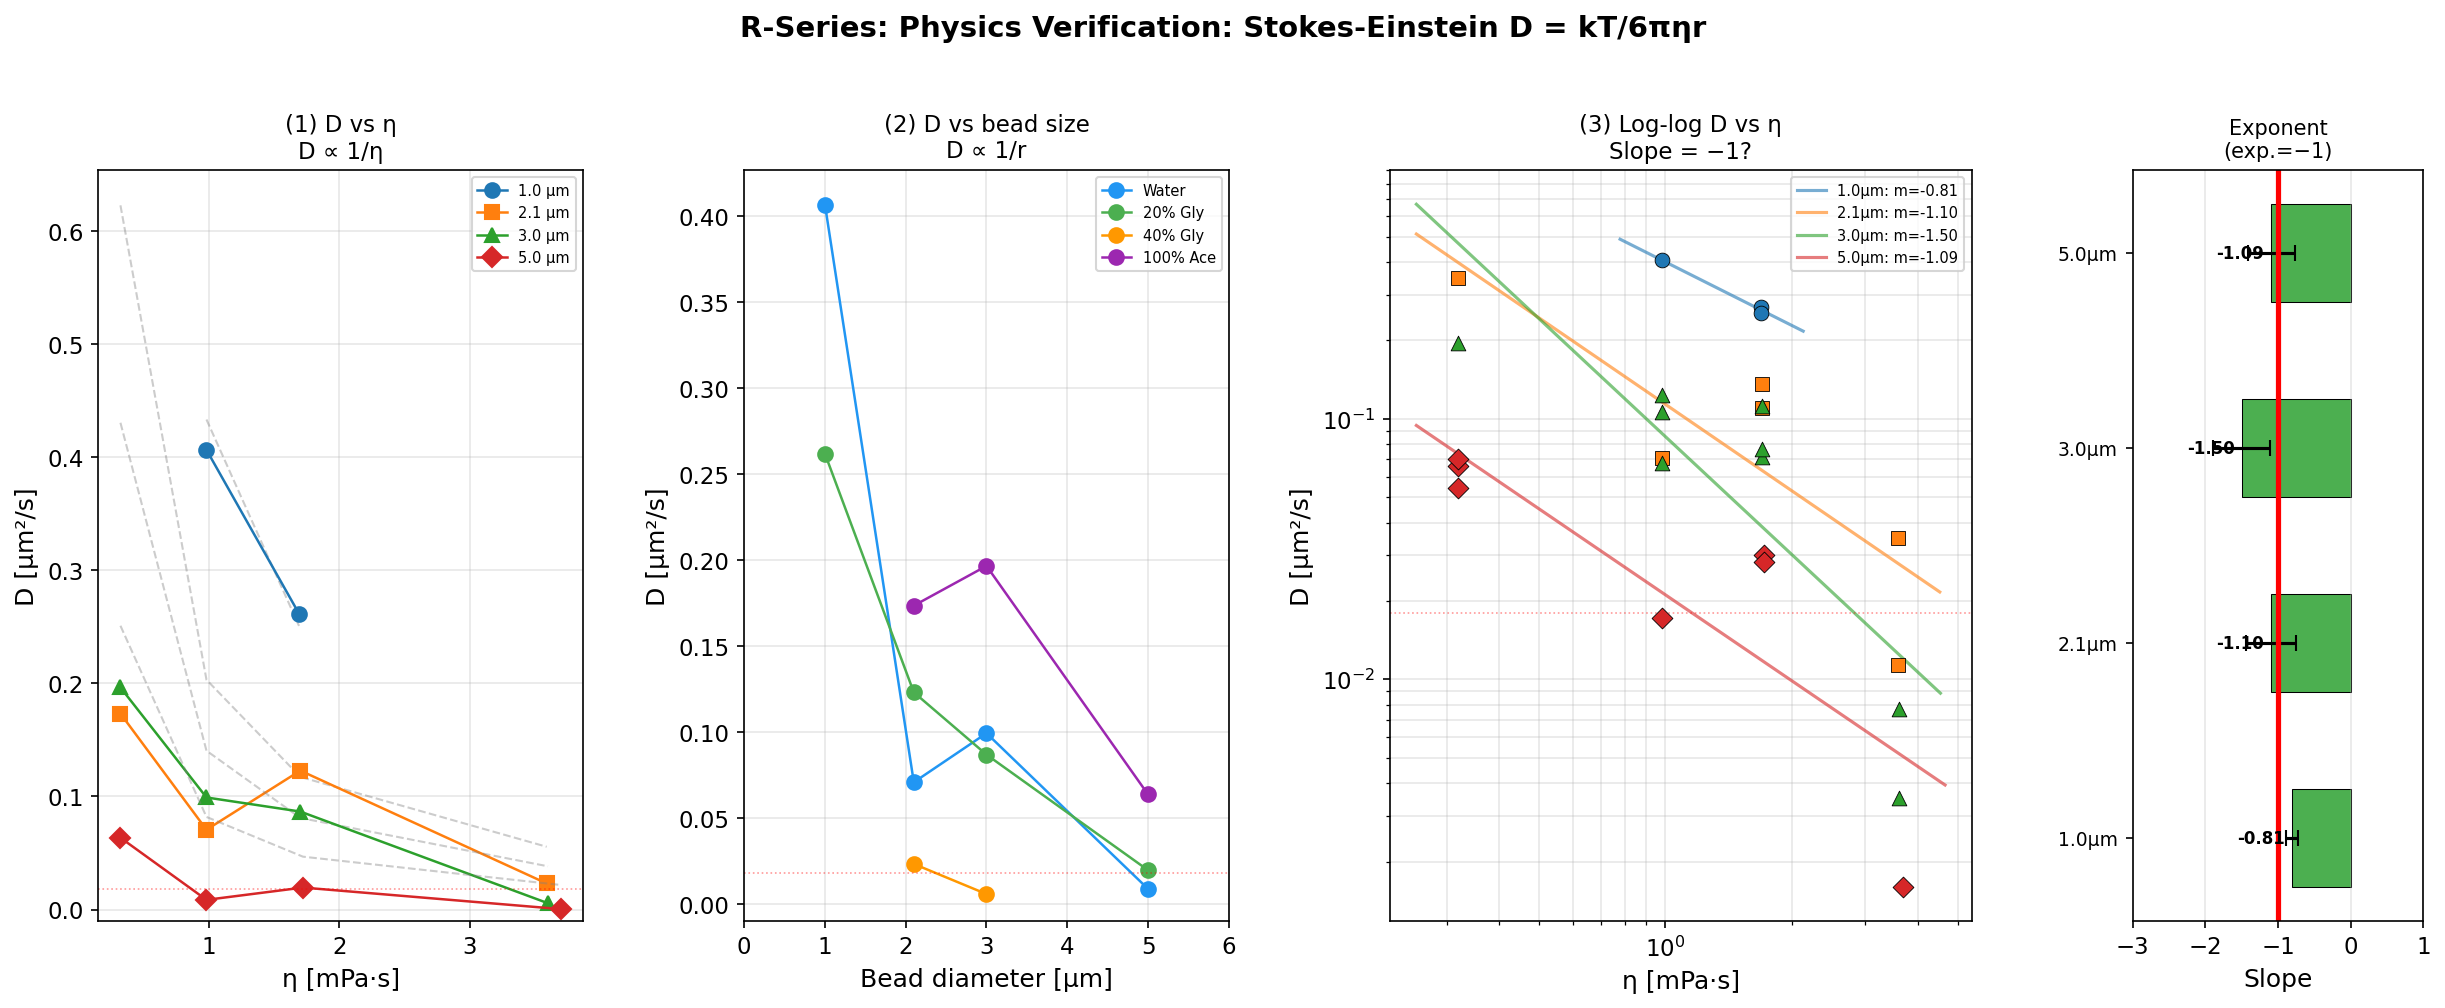

In [17]:
# R-series combined
plot_combined_3results(r_trials, 'R-Series: ',
                       os.path.join(R_SESSION, 'Combined_PhysicsVerification_R-series.png'))

  Saved: Combined_PhysicsVerification_S-series.png
  Skipped fits: 1.0µm: η range=1.0x, 1 distinct


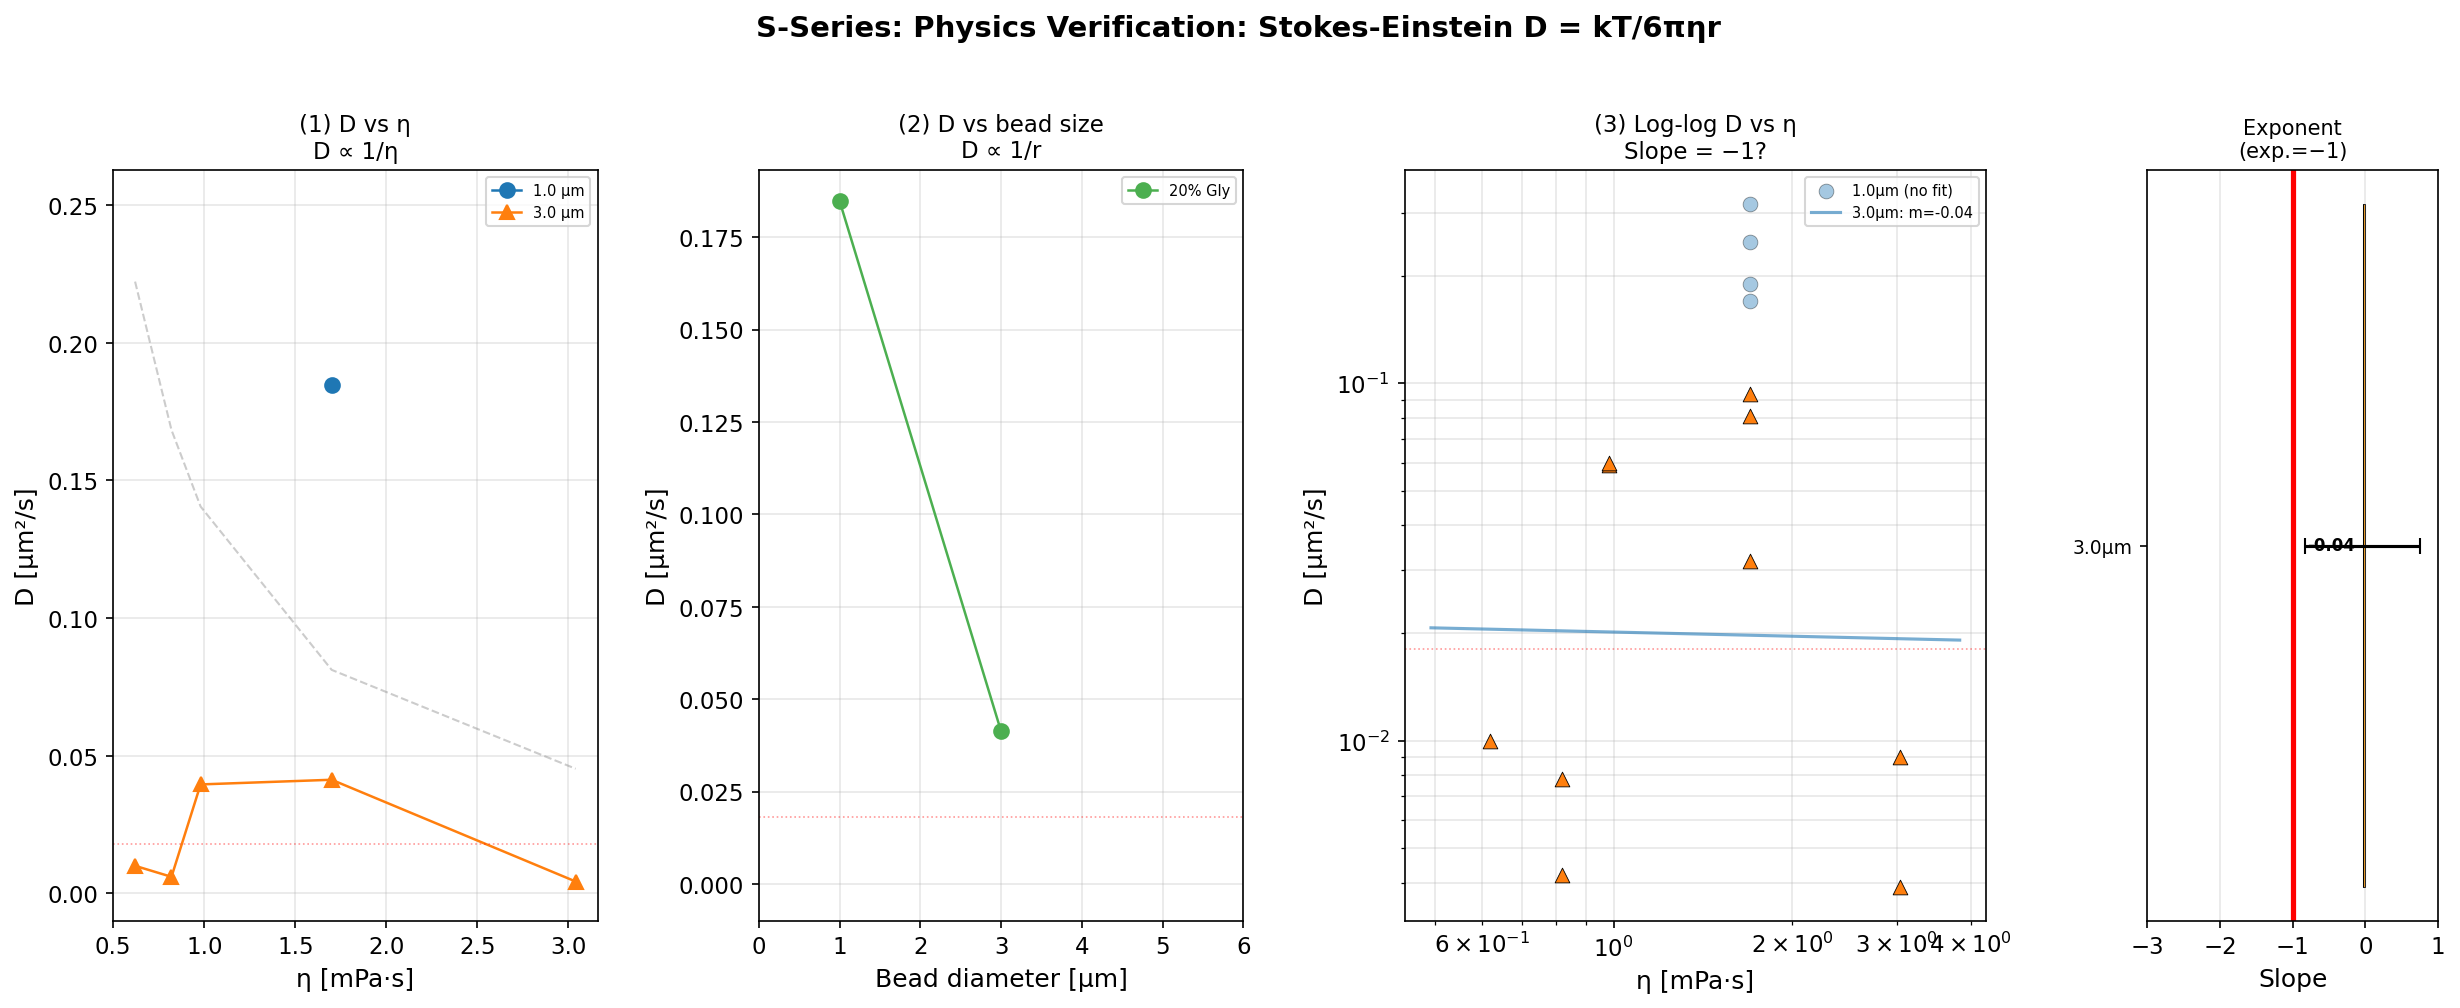

In [18]:
# S-series combined
plot_combined_3results(s_trials, 'S-Series: ',
                       os.path.join(S_SESSION, 'Combined_PhysicsVerification_S-series.png'))

  Saved: Combined_PhysicsVerification_Overall.png


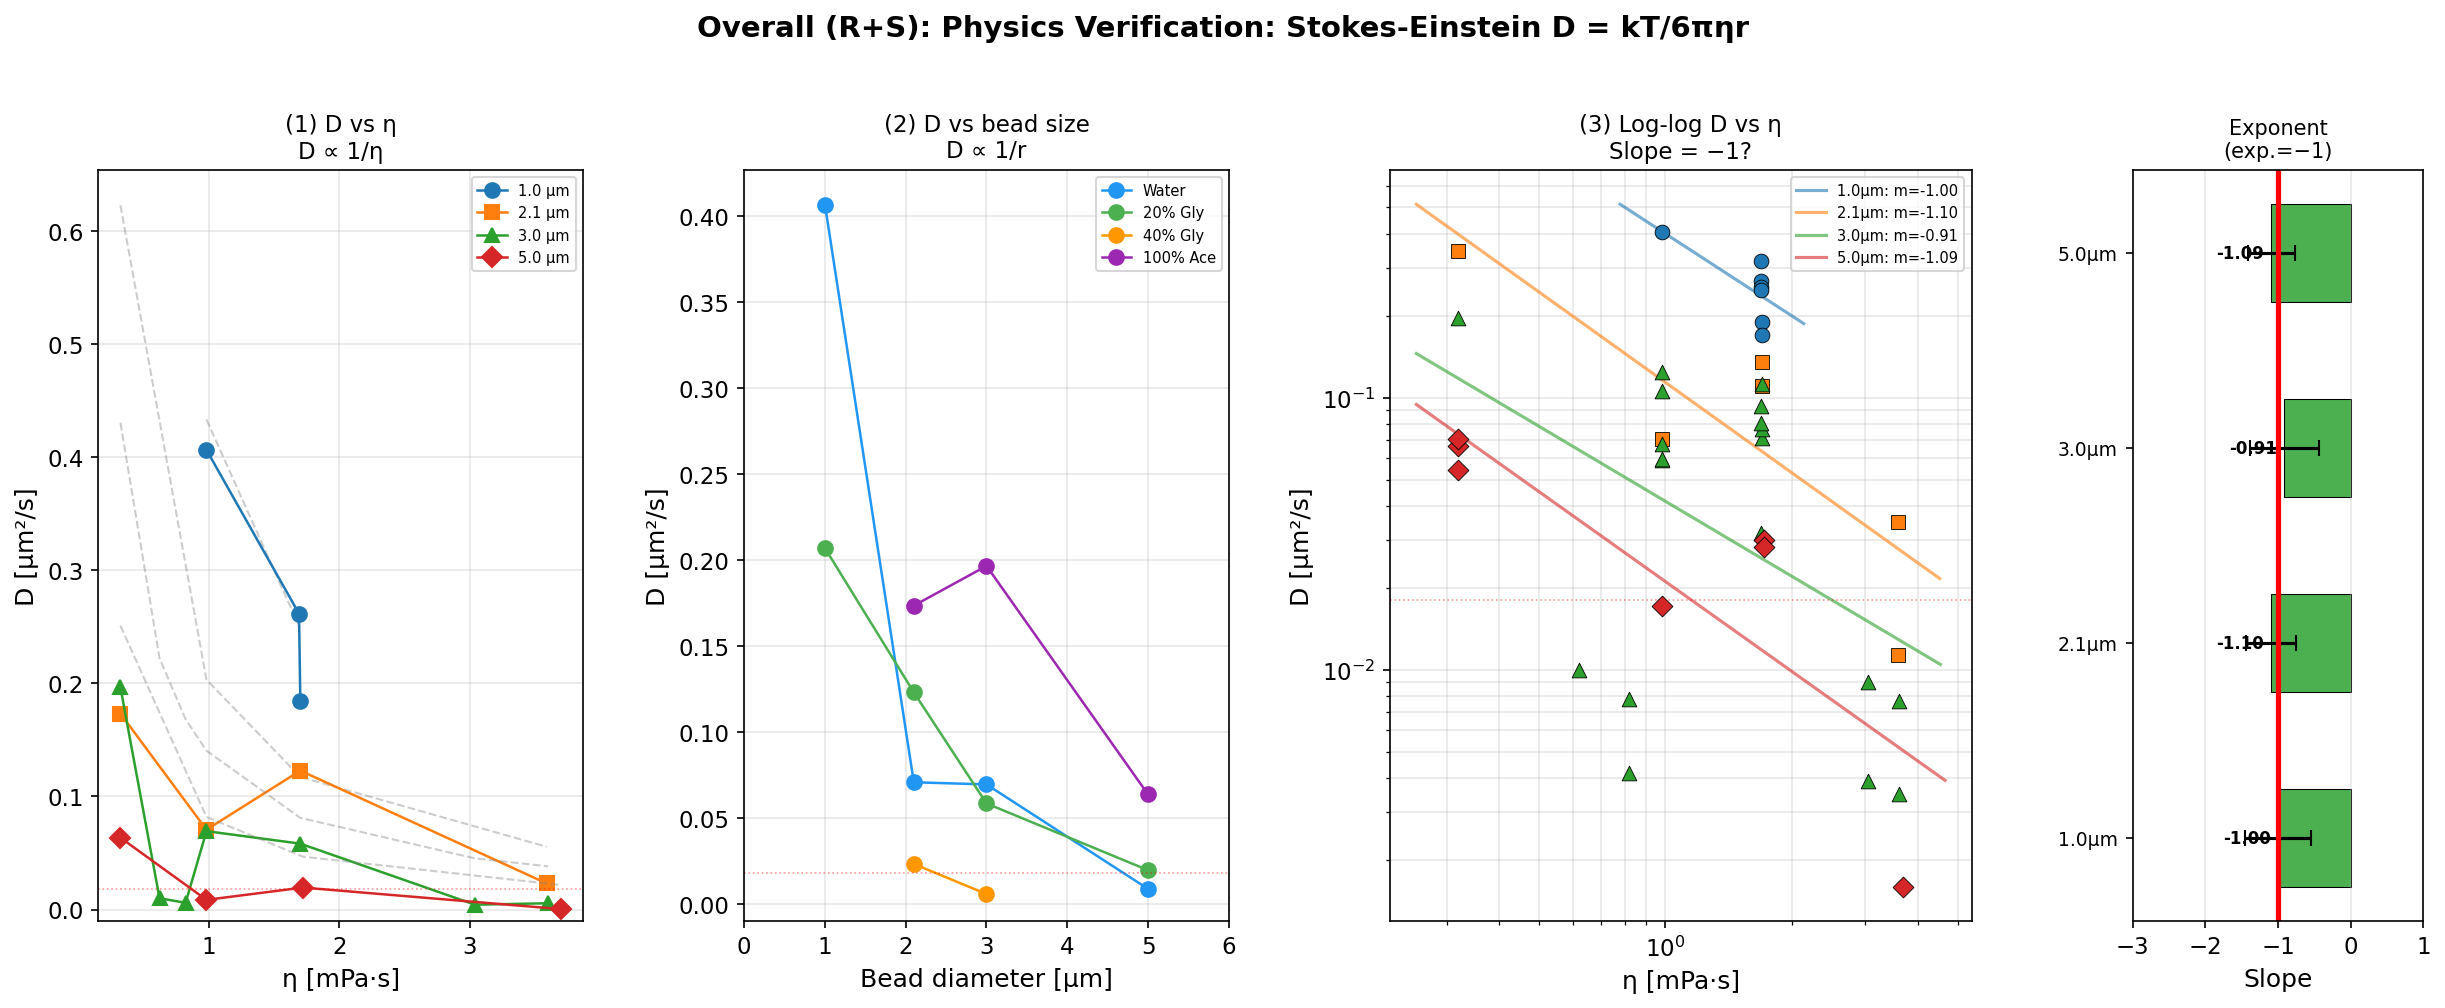

In [19]:
# Overall combined
plot_combined_3results(all_trials, 'Overall (R+S): ',
                       os.path.join(SAVE_DIR, 'Combined_PhysicsVerification_Overall.png'))

---
## Summary Table

Print a concise summary of all fit slopes and alpha statistics for copy-paste into the lab report.

In [20]:
def print_summary(trials, label):
    """Print compact summary of physics verification results.
    Guard: requires >=3 points spanning >=1.5x viscosity range for a valid fit.
    """
    print(f'\n{"=" * 70}')
    print(f'  {label}')
    print(f'{"=" * 70}')
    
    # Alpha stats
    alphas = [t['alpha'] for t in trials if t.get('alpha', 0) > 0.01]
    a_norm = [a for a in alphas if 0.8 <= a <= 1.2]
    print(f'\n  MSD Exponent (Result 2):')
    print(f'    N = {len(alphas)}')
    print(f'    mean  = {np.mean(alphas):.3f}')
    print(f'    median = {np.median(alphas):.3f}')
    print(f'    std   = {np.std(alphas):.3f}')
    print(f'    % in [0.8, 1.2] = {len(a_norm)/len(alphas)*100:.1f}%')
    
    # Log-log slopes (with viscosity range guard)
    print(f'\n  Log-log Slopes (Result 3):')
    bead_groups = group_by(trials, lambda t: t['bead_um'])
    all_slopes = []
    for bead in sorted(bead_groups.keys()):
        rows = bead_groups[bead]
        etas = [r['eta_mPas'] for r in rows if r['eta_mPas'] > 0.01 and r['D_var'] > 0.001]
        ds   = [r['D_var'] for r in rows if r['eta_mPas'] > 0.01 and r['D_var'] > 0.001]
        
        # Guard: need >=3 points AND viscosity range > factor 1.5 AND >=2 distinct eta
        eta_range = max(etas) / min(etas) if etas else 1
        n_distinct_eta = len(set(round(e, 1) for e in etas))
        
        if len(etas) >= 3 and eta_range >= 1.5 and n_distinct_eta >= 2:
            slope, _, r_val, _, std_err = stats.linregress(
                np.log10(etas), np.log10(ds))
            ok = 'PASS' if abs(slope + 1) < 0.5 else 'FAIL'
            print(f'    {bead:5.1f} µm: slope = {slope:+.3f} ± {std_err:.3f}  '
                  f'(R² = {r_val**2:.3f}, N = {len(etas)})  [{ok}]')
            all_slopes.append(slope)
        else:
            reason = f'η range={eta_range:.1f}x, {n_distinct_eta} distinct η, N={len(etas)}'
            print(f'    {bead:5.1f} µm: SKIPPED — insufficient viscosity range ({reason})')
    
    if all_slopes:
        print(f'    ──────────────────────────────')
        print(f'    Mean slope = {np.mean(all_slopes):+.3f} (expected: -1.000)')
    elif not all_slopes:
        print(f'    ──────────────────────────────')
        print(f'    No valid fits — all bead sizes lack sufficient viscosity variation')

print_summary(r_trials, 'R-SERIES (Sessions 7-8, March 3)')
print_summary(s_trials, 'S-SERIES (Sessions 5-6, Feb 26)')
print_summary(all_trials, 'OVERALL (All 50 trials)')


  R-SERIES (Sessions 7-8, March 3)

  MSD Exponent (Result 2):
    N = 31
    mean  = 0.935
    median = 0.940
    std   = 0.196
    % in [0.8, 1.2] = 67.7%

  Log-log Slopes (Result 3):
      1.0 µm: slope = -0.807 ± 0.087  (R² = 0.989, N = 3)  [PASS]
      2.1 µm: slope = -1.099 ± 0.348  (R² = 0.714, N = 6)  [PASS]
      3.0 µm: slope = -1.500 ± 0.394  (R² = 0.675, N = 9)  [PASS]
      5.0 µm: slope = -1.093 ± 0.323  (R² = 0.696, N = 7)  [PASS]
    ──────────────────────────────
    Mean slope = -1.125 (expected: -1.000)

  S-SERIES (Sessions 5-6, Feb 26)

  MSD Exponent (Result 2):
    N = 19
    mean  = 0.914
    median = 0.969
    std   = 0.334
    % in [0.8, 1.2] = 52.6%

  Log-log Slopes (Result 3):
      1.0 µm: SKIPPED — insufficient viscosity range (η range=1.0x, 1 distinct η, N=4)
      3.0 µm: slope = -0.039 ± 0.793  (R² = 0.000, N = 10)  [FAIL]
    ──────────────────────────────
    Mean slope = -0.039 (expected: -1.000)

  OVERALL (All 50 trials)

  MSD Exponent (Result 

---
*Notebook generated for PHYS 382 Lab 2 analysis.*